v0

In [9]:
import os, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Tensorflow 관련 제거하고 Scikit-Learn RandomForest 추가
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, optimizers, callbacks

# Optuna
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.model_selection import StratifiedKFold
import gc
import xgboost as xgb
# =========================
# CONFIG
# =========================
SEED = 1
MODE = "STRICT_CAUSAL"
SPLIT_STRATEGY = "RANDOM_ROW"
POS_RATIO = 0.10
TARGET_TOTAL = 100_000

EPOCHS = 50           # 최종 재학습 epoch
VAL_FRAC = 0.15
TEST_FRAC = 0.15
TIME_HOLDOUT_TEST_WEEKS = 8
TOL = 0.0025

# ✅ Optuna(튜닝) 전용 설정
N_TRIALS = 10             # Optuna trial 수
EPOCHS_TUNE = 15         # 튜닝용 epoch (CV 안에서)
MAX_TUNE_SAMPLES = 30_000  # fold별 train에서 최대 이만큼만 사용

# 최종 평가용 threshold
OPERATING_THR = 0.5
DATA_DIR = "."
# 고정 시드
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED);
rng = np.random.RandomState(SEED)

# 1. Base 데이터 (v0) 로드
path_v0 = os.path.join(DATA_DIR, "featured_v0.parquet")
print(f"[LOAD] Base: {path_v0}")
final_data = pd.read_parquet(path_v0)
print(f"   -> Base Shape: {final_data.shape}")

# 2. v1 ~ v4 순회하며 새로운 컬럼만 병합
versions = ["v1", "v2", "v3", "v4"]

for ver in versions:
    path_ver = os.path.join(DATA_DIR, f"featured_{ver}.parquet")
    if os.path.exists(path_ver):
        print(f"[MERGE] Checking {ver}...")
        temp_df = pd.read_parquet(path_ver)
        
        # v0(현재 final_data)에 없는 컬럼만 추출 (즉, 추가된 A, B, C, D 부분)
        new_cols = [c for c in temp_df.columns if c not in final_data.columns]
        
        if new_cols:
            # 인덱스 기준 병합 (axis=1). 행 순서가 동일하다고 가정합니다.
            # 만약 행 순서가 다르다면 merge(on='id')를 써야 하지만, 
            # 보통 FE 파이프라인 결과물은 순서가 같습니다.
            final_data = pd.concat([final_data, temp_df[new_cols]], axis=1)
            print(f"   -> Added {len(new_cols)} features from {ver} (ex: {new_cols[:3]}...)")
        else:
            print(f"   -> No new features in {ver}")
            
        # 메모리 정리
        del temp_df
        gc.collect()
    else:
        print(f"[WARN] File not found: {path_ver}")

print(f"\n[FINAL DATA] Total Shape: {final_data.shape}")
print("========================================")

# =========================
# 수동 metric + AUC 계산 함수
# =========================
def compute_roc_auc_manual(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    # NaN 제거
    mask = ~np.isnan(y_prob)
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # 확률 내림차순 정렬
    order = np.argsort(-y_prob)
    y_true_sorted = y_true[order]

    cum_pos = np.cumsum(y_true_sorted == 1)
    cum_neg = np.cumsum(y_true_sorted == 0)

    tpr = cum_pos / n_pos
    fpr = cum_neg / n_neg

    # 사다리꼴 적분
    auc = 0.0
    prev_fpr = 0.0
    prev_tpr = 0.0
    for i in range(len(y_true_sorted)):
        auc += (fpr[i] - prev_fpr) * (tpr[i] + prev_tpr) / 2.0
        prev_fpr = fpr[i]
        prev_tpr = tpr[i]

    return float(auc)


# =========================
# 수동 metric + AUC + AIC/BIC 계산 함수
# =========================
def compute_aic_bic_manual(y_true, y_prob, n_features):
    """
    Log-Likelihood를 기반으로 AIC, BIC 계산
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    
    # Log(0) 방지를 위한 clipping (epsilon)
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    # Log Likelihood 계산
    # L = sum( y*log(p) + (1-y)*log(1-p) )
    log_likelihood = np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    
    n = len(y_true)
    k = n_features
    
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    return float(aic), float(bic), float(log_likelihood)

def compute_classification_metrics(y_true, y_prob, thr=0.8, n_features=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= thr).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    n = len(y_true)
    eps = 1e-9

    accuracy    = (tp + tn) / (n + eps)
    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1          = 2 * precision * recall / (precision + recall + eps)

    roc_auc = compute_roc_auc_manual(y_true, y_prob)

    metrics = {
        "accuracy":       float(accuracy),
        "precision":      float(precision),
        "recall":         float(recall),
        "specificity":    float(specificity),
        "f1":             float(f1),
        "roc_auc":        float(roc_auc),
        "n_eval":         int(n),
        "pos_rate_eval":  float(y_true.mean()),
    }

    # [추가됨] n_features가 들어오면 AIC/BIC 계산
    if n_features is not None:
        aic, bic, ll = compute_aic_bic_manual(y_true, y_prob, n_features)
        metrics["aic"] = aic
        metrics["bic"] = bic
        metrics["log_likelihood"] = ll
        metrics["n_features"] = int(n_features)

    cm = (tn, fp, fn, tp)
    return metrics, cm


# =========================
# SPLIT
# =========================
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")

def check_ratio(df, target_ratio=0.10, tol=TOL, name="dataset"):
    if len(df) == 0: return
    r = float(df["is_purchased"].mean())
    ok = abs(r - target_ratio) <= tol
    print(f"[check {name}] pos_rate={r:.6f}  target={target_ratio:.2f}  diff={r-target_ratio:+.6f}  {'OK' if ok else 'WARN'}")

def stratified_fixed_sample(df, target_col="is_purchased", total_n=100_000, pos_ratio=0.10, seed=SEED):
    n_pos_k = int(round(total_n * pos_ratio))
    n_neg_k = total_n - n_pos_k
    pos = df[df[target_col] == 1]
    neg = df[df[target_col] == 0]
    pos_s = pos.sample(n=min(n_pos_k, len(pos)), random_state=seed, replace=False)
    neg_s = neg.sample(n=min(n_neg_k, len(neg)), random_state=seed, replace=False)
    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def split_random_row_simple(df, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    rng_local = np.random.RandomState(seed)
    N = len(df)
    idx = np.arange(N); rng_local.shuffle(idx)
    n_test = int(round(N * test_frac))
    n_val  = int(round(N * val_frac))
    te_idx = idx[:n_test]
    va_idx = idx[n_test:n_test+n_val]
    tr_idx = idx[n_test+n_val:]
    te = df.iloc[te_idx].reset_index(drop=True)
    va = df.iloc[va_idx].reset_index(drop=True)
    tr = df.iloc[tr_idx].reset_index(drop=True)
    return tr, va, te

dataset = final_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
brief("dataset(raw)", dataset)
if TARGET_TOTAL and len(dataset) > TARGET_TOTAL:
    dataset = stratified_fixed_sample(dataset, target_col="is_purchased",
                                      total_n=TARGET_TOTAL, pos_ratio=POS_RATIO, seed=SEED)
brief("dataset(after 100K sampling)", dataset)
check_ratio(dataset, POS_RATIO, name="dataset(100K)")

if SPLIT_STRATEGY == "RANDOM_ROW":
    train_df, val_df, test_df = split_random_row_simple(dataset)
elif SPLIT_STRATEGY == "TIME_HOLDOUT":
    train_df, val_df, test_df = split_time_holdout(dataset)
else:
    train_df, val_df, test_df = split_user_disjoint(dataset)
    
TARGET = "is_purchased"

# =======================================================
# 1. Base Features (v0) - 총 41개
# : 캠페인, 채널, 플랫폼, 기본 이력 통계 등 가장 기초적인 정보
# =======================================================
cols_v0 = [
    'avg_campaign_duration', 'avg_time_since_complaint', 'avg_time_since_first_purchase',
    'avg_time_since_last_click', 'avg_time_since_last_open', 'avg_time_since_unsubscribe',
    'camp_campaign_typebulk', 'camp_campaign_typetransactional', 'camp_campaign_typetrigger',
    'camp_channelemail', 'camp_channelmobile_push', 'camp_channelmultichannel', 'camp_channelsms',
    'camp_topicevent', 'camp_topichappy.birthday', 'camp_topicleave.review',
    'camp_topicoffer.after.purchase', 'camp_topicother', 'camp_topicsale.out',
    'channel_email', 'channel_mobile_push', 'channel_web_push',
    'email_provider_gmail.com', 'email_provider_mail.ru', 'email_provider_other',
    'is_holiday',
    'message_type_bulk', 'message_type_transactional', 'message_type_trigger',
    'platform.', 'platform.desktop', 'platform.phablet', 'platform.smartphone', 'platform.tablet',
    'prev_is_clicked', 'prev_is_complained', 'prev_is_opened', 'prev_is_unsubscribed',
    'total_campaigns', 'total_messages', 'total_purchases'
]

# =======================================================
# 2. Add-on Features (v1) - 총 3개
# : 구매 주기 및 행동 위험도 (Hazard/Refraction)
# =======================================================
cols_v1 = [
    'days_since_last_purchase',
    'feat_rtb_hazard',
    'feat_postbuy_refrac'
]

# =======================================================
# 3. Add-on Features (v2) - 총 6개
# : 캘린더 효과(주말/월초) 및 시간대 이동(Shift)
# =======================================================
cols_v2 = [
    'cal_is_weekend',
    'cal_week_of_month',
    'feat_dow_shift',
    'feat_eoq_bump',
    'feat_hour_shift',
    'feat_payday_bump'
]

# =======================================================
# 4. Add-on Features (v3) - 총 9개
# : 유저 피로도(Fatigue) 및 최근 30일 반응률(Context)
# =======================================================
cols_v3 = [
    'ctx_tc_open_rate_30d',
    'feat_fatigue',
    'feat_last_any_hours',
    'feat_last_email_hours',
    'feat_last_mobile_push_hours',
    'u_cadence_std_30d',
    'u_click_rate_30d',
    'u_open_cnt_30d',
    'u_open_rate_30d'
]

# =======================================================
# 5. Add-on Features (v4) - 총 5개
# : 토픽 신선도 및 행동 경로 유사성 (Sequence/Path)
# =======================================================
cols_v4 = [
    'feat_like_last_success',
    'feat_path_align',
    'feat_topic_novelty',
    'topic_N7',
    'topic_t_since_hours'
]

def get_feat_cols(df):
    """
    데이터프레임에서 학습에 사용할 최종 수치형 변수 리스트를 반환합니다.
    Target과 제외 리스트(ID, Leakage, Collinear)를 필터링합니다.
    """
    # 1. 모든 수치형 컬럼 추출
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # 2. 제외 대상 필터링 (Target + Drop List)
    final_cols = list(cols_v0)# + cols_v1)# + cols_v2 + cols_v3 + cols_v4)
    
    # 3. 정렬 (모델 재현성을 위해 이름순 정렬)
    return sorted(final_cols)

# -------------------------------------------------------
# 실행 및 결과 확인
# -------------------------------------------------------
# train_df는 이미 로드되어 있다고 가정
feat_cols = get_feat_cols(train_df)
n_feat = len(feat_cols)

def prepare_data_3d(df, feature_columns):
    X = df[feature_columns].fillna(0).astype(np.float32).to_numpy()
    Y = df[TARGET].fillna(0).astype(np.int32).to_numpy()
    X_3d = X.reshape(X.shape[0], X.shape[1], 1)  # (N, F, 1)
    return X_3d, Y

Xtr, Ytr = prepare_data_3d(train_df, feat_cols)
Xva, Yva = prepare_data_3d(val_df, feat_cols)
Xte, Yte = prepare_data_3d(test_df, feat_cols)

print("=== Data Shapes ===")
print(f"Train: X={Xtr.shape}, Y={Ytr.shape}")
print(f"Val  : X={Xva.shape}, Y={Yva.shape}")
print(f"Test : X={Xte.shape}, Y={Yte.shape}")


# =========================
# MODEL DEFINITION (CNN) - Dictionary 호환용 수정
# =========================
def build_cnn_model(params, input_shape):
    """
    Optuna trial 대신 확정된 파라미터 딕셔너리(params)를 받아 모델을 생성합니다.
    """
    inp = layers.Input(shape=input_shape)
    x = inp

    # Dictionary에서 파라미터 추출
    conv_filters    = params["conv_filters"]
    kernel_size     = params["kernel_size"]
    pool_size       = params["pool_size"]
    num_conv_layers = params["num_conv_layers"]
    dense_units     = params["dense_units"]
    dropout_rate    = params["dropout_rate"]
    l2_val          = params["l2"]

    for i in range(num_conv_layers):
        x = layers.Conv1D(
            filters=conv_filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="same",
            kernel_regularizer=regularizers.l2(l2_val),
        )(x)
        x = layers.MaxPooling1D(
            pool_size=pool_size,
            padding="same"
        )(x)

    x = layers.GlobalMaxPooling1D()(x)  # 1D CNN 필수

    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_val),
    )(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    return model

# =========================
# RETRAIN WITH BEST PARAMS
# =========================
print("\n[Final] Retraining CNN model with best hyperparameters...")
best_params_cnn = {
      "lr": 0.0001165012459217226,
      "batch_size": 32,
      "conv_filters": 224,
      "kernel_size": 2,
      "pool_size": 3,
      "num_conv_layers": 2,
      "dense_units": 192,
      "dropout_rate": 0.2402219960322026,
      "l2": 0.0014358772473434622
    }

tf.keras.backend.clear_session()

# [수정] create_model 대신 build_cnn_model 사용
final_model = build_cnn_model(best_params_cnn, (n_feat, 1))

opt = optimizers.Adam(learning_rate=best_params_cnn["lr"])
final_model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

es = callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 전체 학습 데이터 사용
history = final_model.fit(
    Xtr, Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=best_params_cnn["batch_size"],
    verbose=1,
    callbacks=[es]
)

# =========================
# FINAL EVALUATION (수동 metric)
# =========================
# [수정] model -> final_model 로 변경
y_prob = final_model.predict(Xte, verbose=0).ravel()
y_true = Yte

# 피처 개수 추출
n_features_used = Xte.shape[1]

# AIC/BIC 계산 포함 평가
final_metrics, (tn, fp, fn, tp) = compute_classification_metrics(
    y_true, y_prob, thr=OPERATING_THR, n_features=n_features_used
)

final_metrics.update({
    "mode": MODE,
    "split": SPLIT_STRATEGY,
    "best_params": best_params_cnn  # [수정] mlp -> cnn
})

print(json.dumps({"metrics": final_metrics}, indent=2))
print("confusion_matrix [tn fp fn tp]:", tn, fp, fn, tp)

[LOAD] Base: ./featured_v0.parquet
   -> Base Shape: (433520, 62)
[MERGE] Checking v1...
   -> Added 3 features from v1 (ex: ['days_since_last_purchase', 'feat_rtb_hazard', 'feat_postbuy_refrac']...)
[MERGE] Checking v2...
   -> Added 7 features from v2 (ex: ['feat_hour_shift', 'feat_dow_shift', 'feat_payday_bump']...)
[MERGE] Checking v3...
   -> Added 45 features from v3 (ex: ['is_hard_bounced', 'hard_bounced_at', 'is_soft_bounced']...)
[MERGE] Checking v4...
   -> Added 7 features from v4 (ex: ['tn_sent_local', 'feat_topic_novelty', 'topic_N7']...)

[FINAL DATA] Total Shape: (579551, 124)
[dataset(raw)] n=579,551  pos=43,352  rate=0.074803
[dataset(after 100K sampling)] n=100,000  pos=10,000  rate=0.100000
[check dataset(100K)] pos_rate=0.100000  target=0.10  diff=+0.000000  OK
=== Data Shapes ===
Train: X=(70000, 41, 1), Y=(70000,)
Val  : X=(15000, 41, 1), Y=(15000,)
Test : X=(15000, 41, 1), Y=(15000,)

[Final] Retraining CNN model with best hyperparameters...
Epoch 1/50
2188/2188 


[Visualizing] Learning Curve와 ROC Curve를 그립니다...


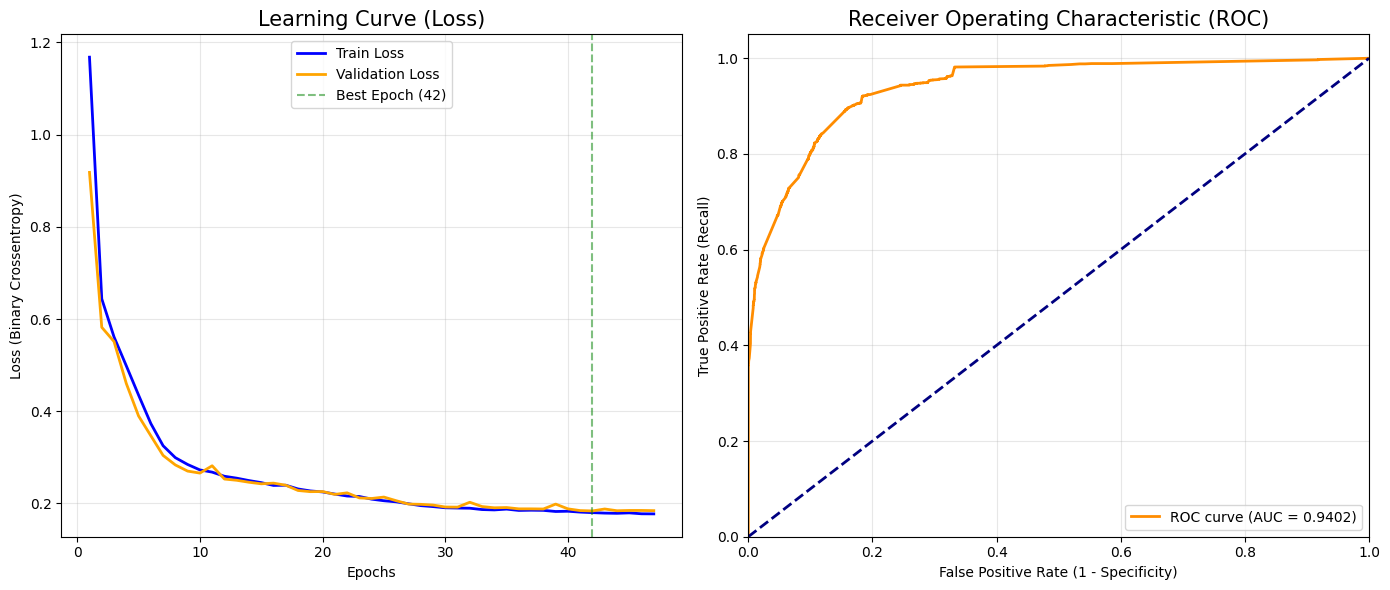

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_performance_graphs(history, y_true, y_prob):
    """
    1. Learning Curve (Loss 변화)
    2. ROC Curve (AUC 포함)
    두 가지 그래프를 나란히 그립니다.
    """
    
    # 캔버스 설정 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 1. Learning Curve (Loss) ---
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(1, len(loss) + 1)
    
    axes[0].plot(epochs_range, loss, label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
    axes[0].set_title('Learning Curve (Loss)', fontsize=15)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Binary Crossentropy)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Early Stopping 등으로 인해 학습이 끊긴 지점 표시 (선택사항)
    best_epoch = np.argmin(val_loss) + 1
    axes[0].axvline(best_epoch, linestyle='--', color='green', alpha=0.5, label=f'Best Epoch ({best_epoch})')
    axes[0].legend()

    # --- 2. ROC Curve & AUC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 기준선
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=15)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행부
# history: model.fit()의 반환 객체
# y_true: 실제값 (Yte)
# y_prob: 모델 예측 확률값
# ==========================================
print("\n[Visualizing] Learning Curve와 ROC Curve를 그립니다...")
plot_performance_graphs(history, y_true, y_prob)

In [7]:
import os, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Tensorflow 관련 제거하고 Scikit-Learn RandomForest 추가
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, optimizers, callbacks

# Optuna
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.model_selection import StratifiedKFold
import gc
import xgboost as xgb
# =========================
# CONFIG
# =========================
SEED = 1
MODE = "STRICT_CAUSAL"
SPLIT_STRATEGY = "RANDOM_ROW"
POS_RATIO = 0.10
TARGET_TOTAL = 100_000

EPOCHS = 50           # 최종 재학습 epoch
VAL_FRAC = 0.15
TEST_FRAC = 0.15
TIME_HOLDOUT_TEST_WEEKS = 8
TOL = 0.0025

# ✅ Optuna(튜닝) 전용 설정
N_TRIALS = 10             # Optuna trial 수
EPOCHS_TUNE = 15         # 튜닝용 epoch (CV 안에서)
MAX_TUNE_SAMPLES = 30_000  # fold별 train에서 최대 이만큼만 사용

# 최종 평가용 threshold
OPERATING_THR = 0.5
DATA_DIR = "."
# 고정 시드
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED);
rng = np.random.RandomState(SEED)

# 1. Base 데이터 (v0) 로드
path_v0 = os.path.join(DATA_DIR, "featured_v0.parquet")
print(f"[LOAD] Base: {path_v0}")
final_data = pd.read_parquet(path_v0)
print(f"   -> Base Shape: {final_data.shape}")

# 2. v1 ~ v4 순회하며 새로운 컬럼만 병합
versions = ["v1", "v2", "v3", "v4"]

for ver in versions:
    path_ver = os.path.join(DATA_DIR, f"featured_{ver}.parquet")
    if os.path.exists(path_ver):
        print(f"[MERGE] Checking {ver}...")
        temp_df = pd.read_parquet(path_ver)
        
        # v0(현재 final_data)에 없는 컬럼만 추출 (즉, 추가된 A, B, C, D 부분)
        new_cols = [c for c in temp_df.columns if c not in final_data.columns]
        
        if new_cols:
            # 인덱스 기준 병합 (axis=1). 행 순서가 동일하다고 가정합니다.
            # 만약 행 순서가 다르다면 merge(on='id')를 써야 하지만, 
            # 보통 FE 파이프라인 결과물은 순서가 같습니다.
            final_data = pd.concat([final_data, temp_df[new_cols]], axis=1)
            print(f"   -> Added {len(new_cols)} features from {ver} (ex: {new_cols[:3]}...)")
        else:
            print(f"   -> No new features in {ver}")
            
        # 메모리 정리
        del temp_df
        gc.collect()
    else:
        print(f"[WARN] File not found: {path_ver}")

print(f"\n[FINAL DATA] Total Shape: {final_data.shape}")
print("========================================")

# =========================
# 수동 metric + AUC 계산 함수
# =========================
def compute_roc_auc_manual(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    # NaN 제거
    mask = ~np.isnan(y_prob)
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # 확률 내림차순 정렬
    order = np.argsort(-y_prob)
    y_true_sorted = y_true[order]

    cum_pos = np.cumsum(y_true_sorted == 1)
    cum_neg = np.cumsum(y_true_sorted == 0)

    tpr = cum_pos / n_pos
    fpr = cum_neg / n_neg

    # 사다리꼴 적분
    auc = 0.0
    prev_fpr = 0.0
    prev_tpr = 0.0
    for i in range(len(y_true_sorted)):
        auc += (fpr[i] - prev_fpr) * (tpr[i] + prev_tpr) / 2.0
        prev_fpr = fpr[i]
        prev_tpr = tpr[i]

    return float(auc)


# =========================
# 수동 metric + AUC + AIC/BIC 계산 함수
# =========================
def compute_aic_bic_manual(y_true, y_prob, n_features):
    """
    Log-Likelihood를 기반으로 AIC, BIC 계산
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    
    # Log(0) 방지를 위한 clipping (epsilon)
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    # Log Likelihood 계산
    # L = sum( y*log(p) + (1-y)*log(1-p) )
    log_likelihood = np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    
    n = len(y_true)
    k = n_features
    
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    return float(aic), float(bic), float(log_likelihood)

def compute_classification_metrics(y_true, y_prob, thr=0.8, n_features=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= thr).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    n = len(y_true)
    eps = 1e-9

    accuracy    = (tp + tn) / (n + eps)
    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1          = 2 * precision * recall / (precision + recall + eps)

    roc_auc = compute_roc_auc_manual(y_true, y_prob)

    metrics = {
        "accuracy":       float(accuracy),
        "precision":      float(precision),
        "recall":         float(recall),
        "specificity":    float(specificity),
        "f1":             float(f1),
        "roc_auc":        float(roc_auc),
        "n_eval":         int(n),
        "pos_rate_eval":  float(y_true.mean()),
    }

    # [추가됨] n_features가 들어오면 AIC/BIC 계산
    if n_features is not None:
        aic, bic, ll = compute_aic_bic_manual(y_true, y_prob, n_features)
        metrics["aic"] = aic
        metrics["bic"] = bic
        metrics["log_likelihood"] = ll
        metrics["n_features"] = int(n_features)

    cm = (tn, fp, fn, tp)
    return metrics, cm


# =========================
# SPLIT
# =========================
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")

def check_ratio(df, target_ratio=0.10, tol=TOL, name="dataset"):
    if len(df) == 0: return
    r = float(df["is_purchased"].mean())
    ok = abs(r - target_ratio) <= tol
    print(f"[check {name}] pos_rate={r:.6f}  target={target_ratio:.2f}  diff={r-target_ratio:+.6f}  {'OK' if ok else 'WARN'}")

def stratified_fixed_sample(df, target_col="is_purchased", total_n=100_000, pos_ratio=0.10, seed=SEED):
    n_pos_k = int(round(total_n * pos_ratio))
    n_neg_k = total_n - n_pos_k
    pos = df[df[target_col] == 1]
    neg = df[df[target_col] == 0]
    pos_s = pos.sample(n=min(n_pos_k, len(pos)), random_state=seed, replace=False)
    neg_s = neg.sample(n=min(n_neg_k, len(neg)), random_state=seed, replace=False)
    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def split_random_row_simple(df, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    rng_local = np.random.RandomState(seed)
    N = len(df)
    idx = np.arange(N); rng_local.shuffle(idx)
    n_test = int(round(N * test_frac))
    n_val  = int(round(N * val_frac))
    te_idx = idx[:n_test]
    va_idx = idx[n_test:n_test+n_val]
    tr_idx = idx[n_test+n_val:]
    te = df.iloc[te_idx].reset_index(drop=True)
    va = df.iloc[va_idx].reset_index(drop=True)
    tr = df.iloc[tr_idx].reset_index(drop=True)
    return tr, va, te

dataset = final_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
brief("dataset(raw)", dataset)
if TARGET_TOTAL and len(dataset) > TARGET_TOTAL:
    dataset = stratified_fixed_sample(dataset, target_col="is_purchased",
                                      total_n=TARGET_TOTAL, pos_ratio=POS_RATIO, seed=SEED)
brief("dataset(after 100K sampling)", dataset)
check_ratio(dataset, POS_RATIO, name="dataset(100K)")

if SPLIT_STRATEGY == "RANDOM_ROW":
    train_df, val_df, test_df = split_random_row_simple(dataset)
elif SPLIT_STRATEGY == "TIME_HOLDOUT":
    train_df, val_df, test_df = split_time_holdout(dataset)
else:
    train_df, val_df, test_df = split_user_disjoint(dataset)
    
TARGET = "is_purchased"

# =======================================================
# 1. Base Features (v0) - 총 41개
# : 캠페인, 채널, 플랫폼, 기본 이력 통계 등 가장 기초적인 정보
# =======================================================
cols_v0 = [
    'avg_campaign_duration', 'avg_time_since_complaint', 'avg_time_since_first_purchase',
    'avg_time_since_last_click', 'avg_time_since_last_open', 'avg_time_since_unsubscribe',
    'camp_campaign_typebulk', 'camp_campaign_typetransactional', 'camp_campaign_typetrigger',
    'camp_channelemail', 'camp_channelmobile_push', 'camp_channelmultichannel', 'camp_channelsms',
    'camp_topicevent', 'camp_topichappy.birthday', 'camp_topicleave.review',
    'camp_topicoffer.after.purchase', 'camp_topicother', 'camp_topicsale.out',
    'channel_email', 'channel_mobile_push', 'channel_web_push',
    'email_provider_gmail.com', 'email_provider_mail.ru', 'email_provider_other',
    'is_holiday',
    'message_type_bulk', 'message_type_transactional', 'message_type_trigger',
    'platform.', 'platform.desktop', 'platform.phablet', 'platform.smartphone', 'platform.tablet',
    'prev_is_clicked', 'prev_is_complained', 'prev_is_opened', 'prev_is_unsubscribed',
    'total_campaigns', 'total_messages', 'total_purchases'
]

# =======================================================
# 2. Add-on Features (v1) - 총 3개
# : 구매 주기 및 행동 위험도 (Hazard/Refraction)
# =======================================================
cols_v1 = [
    'days_since_last_purchase',
    'feat_rtb_hazard',
    'feat_postbuy_refrac'
]

# =======================================================
# 3. Add-on Features (v2) - 총 6개
# : 캘린더 효과(주말/월초) 및 시간대 이동(Shift)
# =======================================================
cols_v2 = [
    'cal_is_weekend',
    'cal_week_of_month',
    'feat_dow_shift',
    'feat_eoq_bump',
    'feat_hour_shift',
    'feat_payday_bump'
]

# =======================================================
# 4. Add-on Features (v3) - 총 9개
# : 유저 피로도(Fatigue) 및 최근 30일 반응률(Context)
# =======================================================
cols_v3 = [
    'ctx_tc_open_rate_30d',
    'feat_fatigue',
    'feat_last_any_hours',
    'feat_last_email_hours',
    'feat_last_mobile_push_hours',
    'u_cadence_std_30d',
    'u_click_rate_30d',
    'u_open_cnt_30d',
    'u_open_rate_30d'
]

# =======================================================
# 5. Add-on Features (v4) - 총 5개
# : 토픽 신선도 및 행동 경로 유사성 (Sequence/Path)
# =======================================================
cols_v4 = [
    'feat_like_last_success',
    'feat_path_align',
    'feat_topic_novelty',
    'topic_N7',
    'topic_t_since_hours'
]

def get_feat_cols(df):
    """
    데이터프레임에서 학습에 사용할 최종 수치형 변수 리스트를 반환합니다.
    Target과 제외 리스트(ID, Leakage, Collinear)를 필터링합니다.
    """
    # 1. 모든 수치형 컬럼 추출
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # 2. 제외 대상 필터링 (Target + Drop List)
    final_cols = list(cols_v0 + cols_v1)# + cols_v2 + cols_v3 + cols_v4)
    
    # 3. 정렬 (모델 재현성을 위해 이름순 정렬)
    return sorted(final_cols)

# -------------------------------------------------------
# 실행 및 결과 확인
# -------------------------------------------------------
# train_df는 이미 로드되어 있다고 가정
feat_cols = get_feat_cols(train_df)
n_feat = len(feat_cols)

def prepare_data_3d(df, feature_columns):
    X = df[feature_columns].fillna(0).astype(np.float32).to_numpy()
    Y = df[TARGET].fillna(0).astype(np.int32).to_numpy()
    X_3d = X.reshape(X.shape[0], X.shape[1], 1)  # (N, F, 1)
    return X_3d, Y

Xtr, Ytr = prepare_data_3d(train_df, feat_cols)
Xva, Yva = prepare_data_3d(val_df, feat_cols)
Xte, Yte = prepare_data_3d(test_df, feat_cols)

print("=== Data Shapes ===")
print(f"Train: X={Xtr.shape}, Y={Ytr.shape}")
print(f"Val  : X={Xva.shape}, Y={Yva.shape}")
print(f"Test : X={Xte.shape}, Y={Yte.shape}")


# =========================
# MODEL DEFINITION (CNN) - Dictionary 호환용 수정
# =========================
def build_cnn_model(params, input_shape):
    """
    Optuna trial 대신 확정된 파라미터 딕셔너리(params)를 받아 모델을 생성합니다.
    """
    inp = layers.Input(shape=input_shape)
    x = inp

    # Dictionary에서 파라미터 추출
    conv_filters    = params["conv_filters"]
    kernel_size     = params["kernel_size"]
    pool_size       = params["pool_size"]
    num_conv_layers = params["num_conv_layers"]
    dense_units     = params["dense_units"]
    dropout_rate    = params["dropout_rate"]
    l2_val          = params["l2"]

    for i in range(num_conv_layers):
        x = layers.Conv1D(
            filters=conv_filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="same",
            kernel_regularizer=regularizers.l2(l2_val),
        )(x)
        x = layers.MaxPooling1D(
            pool_size=pool_size,
            padding="same"
        )(x)

    x = layers.GlobalMaxPooling1D()(x)  # 1D CNN 필수

    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_val),
    )(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    return model

# =========================
# RETRAIN WITH BEST PARAMS
# =========================
print("\n[Final] Retraining CNN model with best hyperparameters...")
best_params_cnn = {
      "lr": 0.0001165012459217226,
      "batch_size": 32,
      "conv_filters": 224,
      "kernel_size": 2,
      "pool_size": 3,
      "num_conv_layers": 2,
      "dense_units": 192,
      "dropout_rate": 0.2402219960322026,
      "l2": 0.0014358772473434622
    }

tf.keras.backend.clear_session()

# [수정] create_model 대신 build_cnn_model 사용
final_model = build_cnn_model(best_params_cnn, (n_feat, 1))

opt = optimizers.Adam(learning_rate=best_params_cnn["lr"])
final_model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

es = callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 전체 학습 데이터 사용
history = final_model.fit(
    Xtr, Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=best_params_cnn["batch_size"],
    verbose=1,
    callbacks=[es]
)

# =========================
# FINAL EVALUATION (수동 metric)
# =========================
# [수정] model -> final_model 로 변경
y_prob = final_model.predict(Xte, verbose=0).ravel()
y_true = Yte

# 피처 개수 추출
n_features_used = Xte.shape[1]

# AIC/BIC 계산 포함 평가
final_metrics, (tn, fp, fn, tp) = compute_classification_metrics(
    y_true, y_prob, thr=OPERATING_THR, n_features=n_features_used
)

final_metrics.update({
    "mode": MODE,
    "split": SPLIT_STRATEGY,
    "best_params": best_params_cnn  # [수정] mlp -> cnn
})

print(json.dumps({"metrics": final_metrics}, indent=2))
print("confusion_matrix [tn fp fn tp]:", tn, fp, fn, tp)

[LOAD] Base: ./featured_v0.parquet
   -> Base Shape: (433520, 62)
[MERGE] Checking v1...
   -> Added 3 features from v1 (ex: ['days_since_last_purchase', 'feat_rtb_hazard', 'feat_postbuy_refrac']...)
[MERGE] Checking v2...
   -> Added 7 features from v2 (ex: ['feat_hour_shift', 'feat_dow_shift', 'feat_payday_bump']...)
[MERGE] Checking v3...
   -> Added 45 features from v3 (ex: ['is_hard_bounced', 'hard_bounced_at', 'is_soft_bounced']...)
[MERGE] Checking v4...
   -> Added 7 features from v4 (ex: ['tn_sent_local', 'feat_topic_novelty', 'topic_N7']...)

[FINAL DATA] Total Shape: (579551, 124)
[dataset(raw)] n=579,551  pos=43,352  rate=0.074803
[dataset(after 100K sampling)] n=100,000  pos=10,000  rate=0.100000
[check dataset(100K)] pos_rate=0.100000  target=0.10  diff=+0.000000  OK
=== Data Shapes ===
Train: X=(70000, 44, 1), Y=(70000,)
Val  : X=(15000, 44, 1), Y=(15000,)
Test : X=(15000, 44, 1), Y=(15000,)

[Final] Retraining CNN model with best hyperparameters...
Epoch 1/50
2188/2188 


[Visualizing] Learning Curve와 ROC Curve를 그립니다...


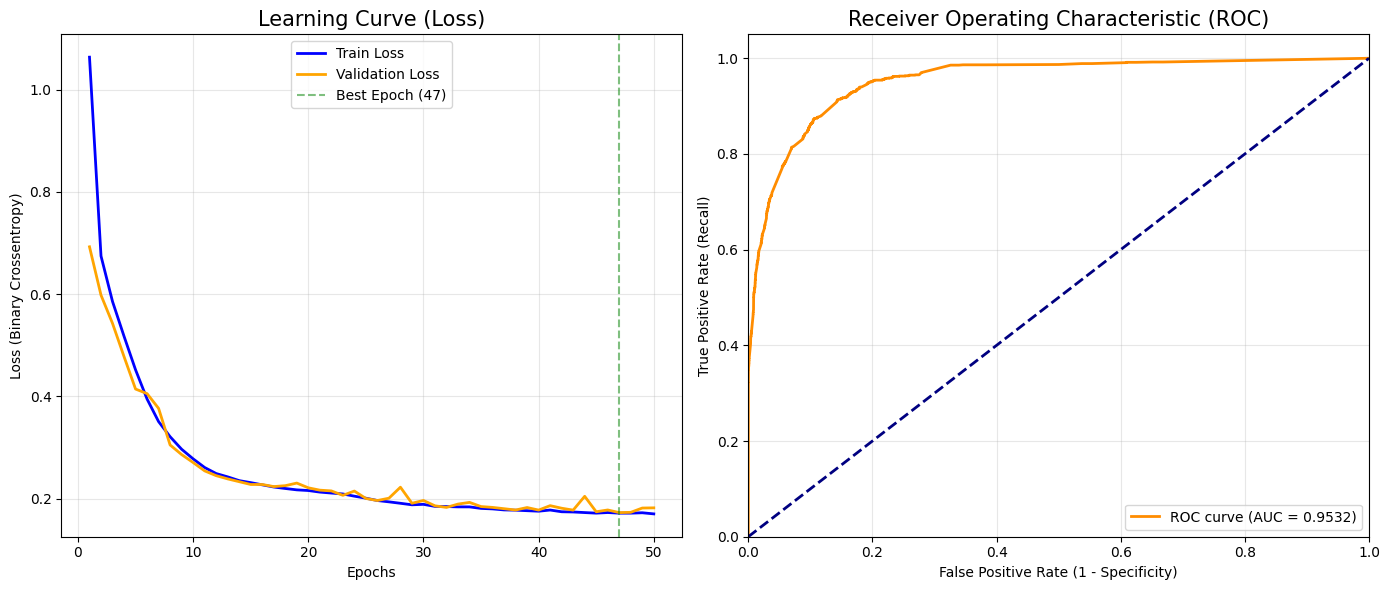

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_performance_graphs(history, y_true, y_prob):
    """
    1. Learning Curve (Loss 변화)
    2. ROC Curve (AUC 포함)
    두 가지 그래프를 나란히 그립니다.
    """
    
    # 캔버스 설정 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 1. Learning Curve (Loss) ---
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(1, len(loss) + 1)
    
    axes[0].plot(epochs_range, loss, label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
    axes[0].set_title('Learning Curve (Loss)', fontsize=15)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Binary Crossentropy)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Early Stopping 등으로 인해 학습이 끊긴 지점 표시 (선택사항)
    best_epoch = np.argmin(val_loss) + 1
    axes[0].axvline(best_epoch, linestyle='--', color='green', alpha=0.5, label=f'Best Epoch ({best_epoch})')
    axes[0].legend()

    # --- 2. ROC Curve & AUC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 기준선
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=15)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행부
# history: model.fit()의 반환 객체
# y_true: 실제값 (Yte)
# y_prob: 모델 예측 확률값
# ==========================================
print("\n[Visualizing] Learning Curve와 ROC Curve를 그립니다...")
plot_performance_graphs(history, y_true, y_prob)

In [11]:
import os, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Tensorflow 관련 제거하고 Scikit-Learn RandomForest 추가
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, optimizers, callbacks

# Optuna
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.model_selection import StratifiedKFold
import gc
import xgboost as xgb
# =========================
# CONFIG
# =========================
SEED = 1
MODE = "STRICT_CAUSAL"
SPLIT_STRATEGY = "RANDOM_ROW"
POS_RATIO = 0.10
TARGET_TOTAL = 100_000

EPOCHS = 50           # 최종 재학습 epoch
VAL_FRAC = 0.15
TEST_FRAC = 0.15
TIME_HOLDOUT_TEST_WEEKS = 8
TOL = 0.0025

# ✅ Optuna(튜닝) 전용 설정
N_TRIALS = 10             # Optuna trial 수
EPOCHS_TUNE = 15         # 튜닝용 epoch (CV 안에서)
MAX_TUNE_SAMPLES = 30_000  # fold별 train에서 최대 이만큼만 사용

# 최종 평가용 threshold
OPERATING_THR = 0.5
DATA_DIR = "."
# 고정 시드
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED);
rng = np.random.RandomState(SEED)

# 1. Base 데이터 (v0) 로드
path_v0 = os.path.join(DATA_DIR, "featured_v0.parquet")
print(f"[LOAD] Base: {path_v0}")
final_data = pd.read_parquet(path_v0)
print(f"   -> Base Shape: {final_data.shape}")

# 2. v1 ~ v4 순회하며 새로운 컬럼만 병합
versions = ["v1", "v2", "v3", "v4"]

for ver in versions:
    path_ver = os.path.join(DATA_DIR, f"featured_{ver}.parquet")
    if os.path.exists(path_ver):
        print(f"[MERGE] Checking {ver}...")
        temp_df = pd.read_parquet(path_ver)
        
        # v0(현재 final_data)에 없는 컬럼만 추출 (즉, 추가된 A, B, C, D 부분)
        new_cols = [c for c in temp_df.columns if c not in final_data.columns]
        
        if new_cols:
            # 인덱스 기준 병합 (axis=1). 행 순서가 동일하다고 가정합니다.
            # 만약 행 순서가 다르다면 merge(on='id')를 써야 하지만, 
            # 보통 FE 파이프라인 결과물은 순서가 같습니다.
            final_data = pd.concat([final_data, temp_df[new_cols]], axis=1)
            print(f"   -> Added {len(new_cols)} features from {ver} (ex: {new_cols[:3]}...)")
        else:
            print(f"   -> No new features in {ver}")
            
        # 메모리 정리
        del temp_df
        gc.collect()
    else:
        print(f"[WARN] File not found: {path_ver}")

print(f"\n[FINAL DATA] Total Shape: {final_data.shape}")
print("========================================")

# =========================
# 수동 metric + AUC 계산 함수
# =========================
def compute_roc_auc_manual(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    # NaN 제거
    mask = ~np.isnan(y_prob)
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # 확률 내림차순 정렬
    order = np.argsort(-y_prob)
    y_true_sorted = y_true[order]

    cum_pos = np.cumsum(y_true_sorted == 1)
    cum_neg = np.cumsum(y_true_sorted == 0)

    tpr = cum_pos / n_pos
    fpr = cum_neg / n_neg

    # 사다리꼴 적분
    auc = 0.0
    prev_fpr = 0.0
    prev_tpr = 0.0
    for i in range(len(y_true_sorted)):
        auc += (fpr[i] - prev_fpr) * (tpr[i] + prev_tpr) / 2.0
        prev_fpr = fpr[i]
        prev_tpr = tpr[i]

    return float(auc)


# =========================
# 수동 metric + AUC + AIC/BIC 계산 함수
# =========================
def compute_aic_bic_manual(y_true, y_prob, n_features):
    """
    Log-Likelihood를 기반으로 AIC, BIC 계산
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    
    # Log(0) 방지를 위한 clipping (epsilon)
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    # Log Likelihood 계산
    # L = sum( y*log(p) + (1-y)*log(1-p) )
    log_likelihood = np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    
    n = len(y_true)
    k = n_features
    
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    return float(aic), float(bic), float(log_likelihood)

def compute_classification_metrics(y_true, y_prob, thr=0.8, n_features=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= thr).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    n = len(y_true)
    eps = 1e-9

    accuracy    = (tp + tn) / (n + eps)
    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1          = 2 * precision * recall / (precision + recall + eps)

    roc_auc = compute_roc_auc_manual(y_true, y_prob)

    metrics = {
        "accuracy":       float(accuracy),
        "precision":      float(precision),
        "recall":         float(recall),
        "specificity":    float(specificity),
        "f1":             float(f1),
        "roc_auc":        float(roc_auc),
        "n_eval":         int(n),
        "pos_rate_eval":  float(y_true.mean()),
    }

    # [추가됨] n_features가 들어오면 AIC/BIC 계산
    if n_features is not None:
        aic, bic, ll = compute_aic_bic_manual(y_true, y_prob, n_features)
        metrics["aic"] = aic
        metrics["bic"] = bic
        metrics["log_likelihood"] = ll
        metrics["n_features"] = int(n_features)

    cm = (tn, fp, fn, tp)
    return metrics, cm


# =========================
# SPLIT
# =========================
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")

def check_ratio(df, target_ratio=0.10, tol=TOL, name="dataset"):
    if len(df) == 0: return
    r = float(df["is_purchased"].mean())
    ok = abs(r - target_ratio) <= tol
    print(f"[check {name}] pos_rate={r:.6f}  target={target_ratio:.2f}  diff={r-target_ratio:+.6f}  {'OK' if ok else 'WARN'}")

def stratified_fixed_sample(df, target_col="is_purchased", total_n=100_000, pos_ratio=0.10, seed=SEED):
    n_pos_k = int(round(total_n * pos_ratio))
    n_neg_k = total_n - n_pos_k
    pos = df[df[target_col] == 1]
    neg = df[df[target_col] == 0]
    pos_s = pos.sample(n=min(n_pos_k, len(pos)), random_state=seed, replace=False)
    neg_s = neg.sample(n=min(n_neg_k, len(neg)), random_state=seed, replace=False)
    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def split_random_row_simple(df, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    rng_local = np.random.RandomState(seed)
    N = len(df)
    idx = np.arange(N); rng_local.shuffle(idx)
    n_test = int(round(N * test_frac))
    n_val  = int(round(N * val_frac))
    te_idx = idx[:n_test]
    va_idx = idx[n_test:n_test+n_val]
    tr_idx = idx[n_test+n_val:]
    te = df.iloc[te_idx].reset_index(drop=True)
    va = df.iloc[va_idx].reset_index(drop=True)
    tr = df.iloc[tr_idx].reset_index(drop=True)
    return tr, va, te

dataset = final_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
brief("dataset(raw)", dataset)
if TARGET_TOTAL and len(dataset) > TARGET_TOTAL:
    dataset = stratified_fixed_sample(dataset, target_col="is_purchased",
                                      total_n=TARGET_TOTAL, pos_ratio=POS_RATIO, seed=SEED)
brief("dataset(after 100K sampling)", dataset)
check_ratio(dataset, POS_RATIO, name="dataset(100K)")

if SPLIT_STRATEGY == "RANDOM_ROW":
    train_df, val_df, test_df = split_random_row_simple(dataset)
elif SPLIT_STRATEGY == "TIME_HOLDOUT":
    train_df, val_df, test_df = split_time_holdout(dataset)
else:
    train_df, val_df, test_df = split_user_disjoint(dataset)
    
TARGET = "is_purchased"

# =======================================================
# 1. Base Features (v0) - 총 41개
# : 캠페인, 채널, 플랫폼, 기본 이력 통계 등 가장 기초적인 정보
# =======================================================
cols_v0 = [
    'avg_campaign_duration', 'avg_time_since_complaint', 'avg_time_since_first_purchase',
    'avg_time_since_last_click', 'avg_time_since_last_open', 'avg_time_since_unsubscribe',
    'camp_campaign_typebulk', 'camp_campaign_typetransactional', 'camp_campaign_typetrigger',
    'camp_channelemail', 'camp_channelmobile_push', 'camp_channelmultichannel', 'camp_channelsms',
    'camp_topicevent', 'camp_topichappy.birthday', 'camp_topicleave.review',
    'camp_topicoffer.after.purchase', 'camp_topicother', 'camp_topicsale.out',
    'channel_email', 'channel_mobile_push', 'channel_web_push',
    'email_provider_gmail.com', 'email_provider_mail.ru', 'email_provider_other',
    'is_holiday',
    'message_type_bulk', 'message_type_transactional', 'message_type_trigger',
    'platform.', 'platform.desktop', 'platform.phablet', 'platform.smartphone', 'platform.tablet',
    'prev_is_clicked', 'prev_is_complained', 'prev_is_opened', 'prev_is_unsubscribed',
    'total_campaigns', 'total_messages', 'total_purchases'
]

# =======================================================
# 2. Add-on Features (v1) - 총 3개
# : 구매 주기 및 행동 위험도 (Hazard/Refraction)
# =======================================================
cols_v1 = [
    'days_since_last_purchase',
    'feat_rtb_hazard',
    'feat_postbuy_refrac'
]

# =======================================================
# 3. Add-on Features (v2) - 총 6개
# : 캘린더 효과(주말/월초) 및 시간대 이동(Shift)
# =======================================================
cols_v2 = [
    'cal_is_weekend',
    'cal_week_of_month',
    'feat_dow_shift',
    'feat_eoq_bump',
    'feat_hour_shift',
    'feat_payday_bump'
]

# =======================================================
# 4. Add-on Features (v3) - 총 9개
# : 유저 피로도(Fatigue) 및 최근 30일 반응률(Context)
# =======================================================
cols_v3 = [
    'ctx_tc_open_rate_30d',
    'feat_fatigue',
    'feat_last_any_hours',
    'feat_last_email_hours',
    'feat_last_mobile_push_hours',
    'u_cadence_std_30d',
    'u_click_rate_30d',
    'u_open_cnt_30d',
    'u_open_rate_30d'
]

# =======================================================
# 5. Add-on Features (v4) - 총 5개
# : 토픽 신선도 및 행동 경로 유사성 (Sequence/Path)
# =======================================================
cols_v4 = [
    'feat_like_last_success',
    'feat_path_align',
    'feat_topic_novelty',
    'topic_N7',
    'topic_t_since_hours'
]

def get_feat_cols(df):
    """
    데이터프레임에서 학습에 사용할 최종 수치형 변수 리스트를 반환합니다.
    Target과 제외 리스트(ID, Leakage, Collinear)를 필터링합니다.
    """
    # 1. 모든 수치형 컬럼 추출
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # 2. 제외 대상 필터링 (Target + Drop List)
    final_cols = list(cols_v0 + cols_v2)# + cols_v2 + cols_v3 + cols_v4)
    
    # 3. 정렬 (모델 재현성을 위해 이름순 정렬)
    return sorted(final_cols)

# -------------------------------------------------------
# 실행 및 결과 확인
# -------------------------------------------------------
# train_df는 이미 로드되어 있다고 가정
feat_cols = get_feat_cols(train_df)
n_feat = len(feat_cols)

def prepare_data_3d(df, feature_columns):
    X = df[feature_columns].fillna(0).astype(np.float32).to_numpy()
    Y = df[TARGET].fillna(0).astype(np.int32).to_numpy()
    X_3d = X.reshape(X.shape[0], X.shape[1], 1)  # (N, F, 1)
    return X_3d, Y

Xtr, Ytr = prepare_data_3d(train_df, feat_cols)
Xva, Yva = prepare_data_3d(val_df, feat_cols)
Xte, Yte = prepare_data_3d(test_df, feat_cols)

print("=== Data Shapes ===")
print(f"Train: X={Xtr.shape}, Y={Ytr.shape}")
print(f"Val  : X={Xva.shape}, Y={Yva.shape}")
print(f"Test : X={Xte.shape}, Y={Yte.shape}")


# =========================
# MODEL DEFINITION (CNN) - Dictionary 호환용 수정
# =========================
def build_cnn_model(params, input_shape):
    """
    Optuna trial 대신 확정된 파라미터 딕셔너리(params)를 받아 모델을 생성합니다.
    """
    inp = layers.Input(shape=input_shape)
    x = inp

    # Dictionary에서 파라미터 추출
    conv_filters    = params["conv_filters"]
    kernel_size     = params["kernel_size"]
    pool_size       = params["pool_size"]
    num_conv_layers = params["num_conv_layers"]
    dense_units     = params["dense_units"]
    dropout_rate    = params["dropout_rate"]
    l2_val          = params["l2"]

    for i in range(num_conv_layers):
        x = layers.Conv1D(
            filters=conv_filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="same",
            kernel_regularizer=regularizers.l2(l2_val),
        )(x)
        x = layers.MaxPooling1D(
            pool_size=pool_size,
            padding="same"
        )(x)

    x = layers.GlobalMaxPooling1D()(x)  # 1D CNN 필수

    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_val),
    )(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    return model

# =========================
# RETRAIN WITH BEST PARAMS
# =========================
print("\n[Final] Retraining CNN model with best hyperparameters...")
best_params_cnn = {
      "lr": 0.0001165012459217226,
      "batch_size": 32,
      "conv_filters": 224,
      "kernel_size": 2,
      "pool_size": 3,
      "num_conv_layers": 2,
      "dense_units": 192,
      "dropout_rate": 0.2402219960322026,
      "l2": 0.0014358772473434622
    }

tf.keras.backend.clear_session()

# [수정] create_model 대신 build_cnn_model 사용
final_model = build_cnn_model(best_params_cnn, (n_feat, 1))

opt = optimizers.Adam(learning_rate=best_params_cnn["lr"])
final_model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

es = callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 전체 학습 데이터 사용
history = final_model.fit(
    Xtr, Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=best_params_cnn["batch_size"],
    verbose=1,
    callbacks=[es]
)

# =========================
# FINAL EVALUATION (수동 metric)
# =========================
# [수정] model -> final_model 로 변경
y_prob = final_model.predict(Xte, verbose=0).ravel()
y_true = Yte

# 피처 개수 추출
n_features_used = Xte.shape[1]

# AIC/BIC 계산 포함 평가
final_metrics, (tn, fp, fn, tp) = compute_classification_metrics(
    y_true, y_prob, thr=OPERATING_THR, n_features=n_features_used
)

final_metrics.update({
    "mode": MODE,
    "split": SPLIT_STRATEGY,
    "best_params": best_params_cnn  # [수정] mlp -> cnn
})

print(json.dumps({"metrics": final_metrics}, indent=2))
print("confusion_matrix [tn fp fn tp]:", tn, fp, fn, tp)

[LOAD] Base: ./featured_v0.parquet
   -> Base Shape: (433520, 62)
[MERGE] Checking v1...
   -> Added 3 features from v1 (ex: ['days_since_last_purchase', 'feat_rtb_hazard', 'feat_postbuy_refrac']...)
[MERGE] Checking v2...
   -> Added 7 features from v2 (ex: ['feat_hour_shift', 'feat_dow_shift', 'feat_payday_bump']...)
[MERGE] Checking v3...
   -> Added 45 features from v3 (ex: ['is_hard_bounced', 'hard_bounced_at', 'is_soft_bounced']...)
[MERGE] Checking v4...
   -> Added 7 features from v4 (ex: ['tn_sent_local', 'feat_topic_novelty', 'topic_N7']...)

[FINAL DATA] Total Shape: (579551, 124)
[dataset(raw)] n=579,551  pos=43,352  rate=0.074803
[dataset(after 100K sampling)] n=100,000  pos=10,000  rate=0.100000
[check dataset(100K)] pos_rate=0.100000  target=0.10  diff=+0.000000  OK
=== Data Shapes ===
Train: X=(70000, 47, 1), Y=(70000,)
Val  : X=(15000, 47, 1), Y=(15000,)
Test : X=(15000, 47, 1), Y=(15000,)

[Final] Retraining CNN model with best hyperparameters...
Epoch 1/50
2188/2188 


[Visualizing] Learning Curve와 ROC Curve를 그립니다...


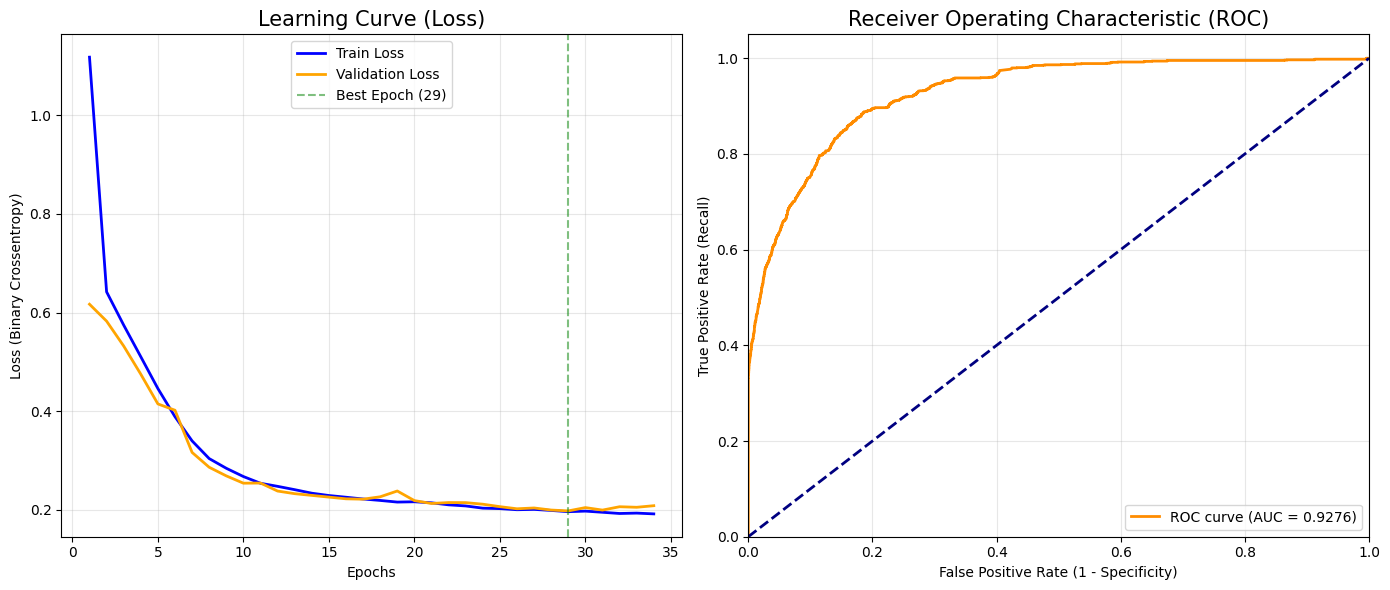

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_performance_graphs(history, y_true, y_prob):
    """
    1. Learning Curve (Loss 변화)
    2. ROC Curve (AUC 포함)
    두 가지 그래프를 나란히 그립니다.
    """
    
    # 캔버스 설정 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 1. Learning Curve (Loss) ---
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(1, len(loss) + 1)
    
    axes[0].plot(epochs_range, loss, label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
    axes[0].set_title('Learning Curve (Loss)', fontsize=15)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Binary Crossentropy)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Early Stopping 등으로 인해 학습이 끊긴 지점 표시 (선택사항)
    best_epoch = np.argmin(val_loss) + 1
    axes[0].axvline(best_epoch, linestyle='--', color='green', alpha=0.5, label=f'Best Epoch ({best_epoch})')
    axes[0].legend()

    # --- 2. ROC Curve & AUC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 기준선
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=15)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행부
# history: model.fit()의 반환 객체
# y_true: 실제값 (Yte)
# y_prob: 모델 예측 확률값
# ==========================================
print("\n[Visualizing] Learning Curve와 ROC Curve를 그립니다...")
plot_performance_graphs(history, y_true, y_prob)

In [1]:
import os, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Tensorflow 관련 제거하고 Scikit-Learn RandomForest 추가
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, optimizers, callbacks

# Optuna
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.model_selection import StratifiedKFold
import gc
import xgboost as xgb
# =========================
# CONFIG
# =========================
SEED = 1
MODE = "STRICT_CAUSAL"
SPLIT_STRATEGY = "RANDOM_ROW"
POS_RATIO = 0.10
TARGET_TOTAL = 100_000

EPOCHS = 50           # 최종 재학습 epoch
VAL_FRAC = 0.15
TEST_FRAC = 0.15
TIME_HOLDOUT_TEST_WEEKS = 8
TOL = 0.0025

# ✅ Optuna(튜닝) 전용 설정
N_TRIALS = 10             # Optuna trial 수
EPOCHS_TUNE = 15         # 튜닝용 epoch (CV 안에서)
MAX_TUNE_SAMPLES = 30_000  # fold별 train에서 최대 이만큼만 사용

# 최종 평가용 threshold
OPERATING_THR = 0.5
DATA_DIR = "."
# 고정 시드
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED);
rng = np.random.RandomState(SEED)

# 1. Base 데이터 (v0) 로드
path_v0 = os.path.join(DATA_DIR, "featured_all.parquet")
print(f"[LOAD] Base: {path_v0}")
final_data = pd.read_parquet(path_v0)

print(f"\n[FINAL DATA] Total Shape: {final_data.shape}")
print("========================================")
# =========================
# 수동 metric + AUC 계산 함수
# =========================
def compute_roc_auc_manual(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    # NaN 제거
    mask = ~np.isnan(y_prob)
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # 확률 내림차순 정렬
    order = np.argsort(-y_prob)
    y_true_sorted = y_true[order]

    cum_pos = np.cumsum(y_true_sorted == 1)
    cum_neg = np.cumsum(y_true_sorted == 0)

    tpr = cum_pos / n_pos
    fpr = cum_neg / n_neg

    # 사다리꼴 적분
    auc = 0.0
    prev_fpr = 0.0
    prev_tpr = 0.0
    for i in range(len(y_true_sorted)):
        auc += (fpr[i] - prev_fpr) * (tpr[i] + prev_tpr) / 2.0
        prev_fpr = fpr[i]
        prev_tpr = tpr[i]

    return float(auc)


# =========================
# 수동 metric + AUC + AIC/BIC 계산 함수
# =========================
def compute_aic_bic_manual(y_true, y_prob, n_features):
    """
    Log-Likelihood를 기반으로 AIC, BIC 계산
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    
    # Log(0) 방지를 위한 clipping (epsilon)
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    # Log Likelihood 계산
    # L = sum( y*log(p) + (1-y)*log(1-p) )
    log_likelihood = np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    
    n = len(y_true)
    k = n_features
    
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    return float(aic), float(bic), float(log_likelihood)

def compute_classification_metrics(y_true, y_prob, thr=0.8, n_features=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= thr).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    n = len(y_true)
    eps = 1e-9

    accuracy    = (tp + tn) / (n + eps)
    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1          = 2 * precision * recall / (precision + recall + eps)

    roc_auc = compute_roc_auc_manual(y_true, y_prob)

    metrics = {
        "accuracy":       float(accuracy),
        "precision":      float(precision),
        "recall":         float(recall),
        "specificity":    float(specificity),
        "f1":             float(f1),
        "roc_auc":        float(roc_auc),
        "n_eval":         int(n),
        "pos_rate_eval":  float(y_true.mean()),
    }

    # [추가됨] n_features가 들어오면 AIC/BIC 계산
    if n_features is not None:
        aic, bic, ll = compute_aic_bic_manual(y_true, y_prob, n_features)
        metrics["aic"] = aic
        metrics["bic"] = bic
        metrics["log_likelihood"] = ll
        metrics["n_features"] = int(n_features)

    cm = (tn, fp, fn, tp)
    return metrics, cm


# =========================
# SPLIT
# =========================
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")

def check_ratio(df, target_ratio=0.10, tol=TOL, name="dataset"):
    if len(df) == 0: return
    r = float(df["is_purchased"].mean())
    ok = abs(r - target_ratio) <= tol
    print(f"[check {name}] pos_rate={r:.6f}  target={target_ratio:.2f}  diff={r-target_ratio:+.6f}  {'OK' if ok else 'WARN'}")

def stratified_fixed_sample(df, target_col="is_purchased", total_n=100_000, pos_ratio=0.10, seed=SEED):
    n_pos_k = int(round(total_n * pos_ratio))
    n_neg_k = total_n - n_pos_k
    pos = df[df[target_col] == 1]
    neg = df[df[target_col] == 0]
    pos_s = pos.sample(n=min(n_pos_k, len(pos)), random_state=seed, replace=False)
    neg_s = neg.sample(n=min(n_neg_k, len(neg)), random_state=seed, replace=False)
    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def split_random_row_simple(df, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    rng_local = np.random.RandomState(seed)
    N = len(df)
    idx = np.arange(N); rng_local.shuffle(idx)
    n_test = int(round(N * test_frac))
    n_val  = int(round(N * val_frac))
    te_idx = idx[:n_test]
    va_idx = idx[n_test:n_test+n_val]
    tr_idx = idx[n_test+n_val:]
    te = df.iloc[te_idx].reset_index(drop=True)
    va = df.iloc[va_idx].reset_index(drop=True)
    tr = df.iloc[tr_idx].reset_index(drop=True)
    return tr, va, te

dataset = final_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
brief("dataset(raw)", dataset)
if TARGET_TOTAL and len(dataset) > TARGET_TOTAL:
    dataset = stratified_fixed_sample(dataset, target_col="is_purchased",
                                      total_n=TARGET_TOTAL, pos_ratio=POS_RATIO, seed=SEED)
brief("dataset(after 100K sampling)", dataset)
check_ratio(dataset, POS_RATIO, name="dataset(100K)")

if SPLIT_STRATEGY == "RANDOM_ROW":
    train_df, val_df, test_df = split_random_row_simple(dataset)
elif SPLIT_STRATEGY == "TIME_HOLDOUT":
    train_df, val_df, test_df = split_time_holdout(dataset)
else:
    train_df, val_df, test_df = split_user_disjoint(dataset)
    
TARGET = "is_purchased"

# =======================================================
# 1. Base Features (v0) - 총 41개
# : 캠페인, 채널, 플랫폼, 기본 이력 통계 등 가장 기초적인 정보
# =======================================================
cols_v0 = [
    'avg_campaign_duration', 'avg_time_since_complaint', 'avg_time_since_first_purchase',
    'avg_time_since_last_click', 'avg_time_since_last_open', 'avg_time_since_unsubscribe',
    'camp_campaign_typebulk', 'camp_campaign_typetransactional', 'camp_campaign_typetrigger',
    'camp_channelemail', 'camp_channelmobile_push', 'camp_channelmultichannel', 'camp_channelsms',
    'camp_topicevent', 'camp_topichappy.birthday', 'camp_topicleave.review',
    'camp_topicoffer.after.purchase', 'camp_topicother', 'camp_topicsale.out',
    'channel_email', 'channel_mobile_push', 'channel_web_push',
    'email_provider_gmail.com', 'email_provider_mail.ru', 'email_provider_other',
    'is_holiday',
    'message_type_bulk', 'message_type_transactional', 'message_type_trigger',
    'platform.', 'platform.desktop', 'platform.phablet', 'platform.smartphone', 'platform.tablet',
    'prev_is_clicked', 'prev_is_complained', 'prev_is_opened', 'prev_is_unsubscribed',
    'total_campaigns', 'total_messages', 'total_purchases'
]

# =======================================================
# 2. Add-on Features (v1) - 총 3개
# : 구매 주기 및 행동 위험도 (Hazard/Refraction)
# =======================================================
cols_v1 = [
    'days_since_last_purchase',
    'feat_rtb_hazard',
    'feat_postbuy_refrac'
]

# =======================================================
# 3. Add-on Features (v2) - 총 6개
# : 캘린더 효과(주말/월초) 및 시간대 이동(Shift)
# =======================================================
cols_v2 = [
    'cal_is_weekend',
    'cal_week_of_month',
    'feat_dow_shift',
    'feat_eoq_bump',
    'feat_hour_shift',
    'feat_payday_bump'
]

# =======================================================
# 4. Add-on Features (v3) - 총 9개
# : 유저 피로도(Fatigue) 및 최근 30일 반응률(Context)
# =======================================================
cols_v3 = [
    'ctx_tc_open_rate_30d',
    'feat_fatigue',
    'feat_last_any_hours',
    'feat_last_email_hours',
    'feat_last_mobile_push_hours',
    'u_cadence_std_30d',
    'u_click_rate_30d',
    'u_open_cnt_30d',
    'u_open_rate_30d'
]

# =======================================================
# 5. Add-on Features (v4) - 총 5개
# : 토픽 신선도 및 행동 경로 유사성 (Sequence/Path)
# =======================================================
cols_v4 = [
    'feat_like_last_success',
    'feat_path_align',
    'feat_topic_novelty',
    'topic_N7',
    'topic_t_since_hours'
]

def get_feat_cols(df):
    """
    데이터프레임에서 학습에 사용할 최종 수치형 변수 리스트를 반환합니다.
    Target과 제외 리스트(ID, Leakage, Collinear)를 필터링합니다.
    """
    # 1. 모든 수치형 컬럼 추출
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # 2. 제외 대상 필터링 (Target + Drop List)
    final_cols = list(cols_v0 + cols_v3)# + cols_v2 + cols_v3 + cols_v4)
    
    # 3. 정렬 (모델 재현성을 위해 이름순 정렬)
    return sorted(final_cols)

# -------------------------------------------------------
# 실행 및 결과 확인
# -------------------------------------------------------
# train_df는 이미 로드되어 있다고 가정
feat_cols = get_feat_cols(train_df)
n_feat = len(feat_cols)

def prepare_data_3d(df, feature_columns):
    X = df[feature_columns].fillna(0).astype(np.float32).to_numpy()
    Y = df[TARGET].fillna(0).astype(np.int32).to_numpy()
    X_3d = X.reshape(X.shape[0], X.shape[1], 1)  # (N, F, 1)
    return X_3d, Y

Xtr, Ytr = prepare_data_3d(train_df, feat_cols)
Xva, Yva = prepare_data_3d(val_df, feat_cols)
Xte, Yte = prepare_data_3d(test_df, feat_cols)

print("=== Data Shapes ===")
print(f"Train: X={Xtr.shape}, Y={Ytr.shape}")
print(f"Val  : X={Xva.shape}, Y={Yva.shape}")
print(f"Test : X={Xte.shape}, Y={Yte.shape}")


# =========================
# MODEL DEFINITION (CNN) - Dictionary 호환용 수정
# =========================
def build_cnn_model(params, input_shape):
    """
    Optuna trial 대신 확정된 파라미터 딕셔너리(params)를 받아 모델을 생성합니다.
    """
    inp = layers.Input(shape=input_shape)
    x = inp

    # Dictionary에서 파라미터 추출
    conv_filters    = params["conv_filters"]
    kernel_size     = params["kernel_size"]
    pool_size       = params["pool_size"]
    num_conv_layers = params["num_conv_layers"]
    dense_units     = params["dense_units"]
    dropout_rate    = params["dropout_rate"]
    l2_val          = params["l2"]

    for i in range(num_conv_layers):
        x = layers.Conv1D(
            filters=conv_filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="same",
            kernel_regularizer=regularizers.l2(l2_val),
        )(x)
        x = layers.MaxPooling1D(
            pool_size=pool_size,
            padding="same"
        )(x)

    x = layers.GlobalMaxPooling1D()(x)  # 1D CNN 필수

    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_val),
    )(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    return model

# =========================
# RETRAIN WITH BEST PARAMS
# =========================
print("\n[Final] Retraining CNN model with best hyperparameters...")
best_params_cnn = {
      "lr": 0.0001165012459217226,
      "batch_size": 32,
      "conv_filters": 224,
      "kernel_size": 2,
      "pool_size": 3,
      "num_conv_layers": 2,
      "dense_units": 192,
      "dropout_rate": 0.2402219960322026,
      "l2": 0.0014358772473434622
    }

tf.keras.backend.clear_session()

# [수정] create_model 대신 build_cnn_model 사용
final_model = build_cnn_model(best_params_cnn, (n_feat, 1))

opt = optimizers.Adam(learning_rate=best_params_cnn["lr"])
final_model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

es = callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 전체 학습 데이터 사용
history = final_model.fit(
    Xtr, Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=best_params_cnn["batch_size"],
    verbose=1,
    callbacks=[es]
)

# =========================
# FINAL EVALUATION (수동 metric)
# =========================
# [수정] model -> final_model 로 변경
y_prob = final_model.predict(Xte, verbose=0).ravel()
y_true = Yte

# 피처 개수 추출
n_features_used = Xte.shape[1]

# AIC/BIC 계산 포함 평가
final_metrics, (tn, fp, fn, tp) = compute_classification_metrics(
    y_true, y_prob, thr=OPERATING_THR, n_features=n_features_used
)

final_metrics.update({
    "mode": MODE,
    "split": SPLIT_STRATEGY,
    "best_params": best_params_cnn  # [수정] mlp -> cnn
})

print(json.dumps({"metrics": final_metrics}, indent=2))
print("confusion_matrix [tn fp fn tp]:", tn, fp, fn, tp)

2025-12-20 18:38:23.691402: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-20 18:38:23.708548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766223503.731097 1005412 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766223503.738232 1005412 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766223503.756043 1005412 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

[LOAD] Base: ./featured_all.parquet

[FINAL DATA] Total Shape: (433520, 124)
[dataset(raw)] n=433,520  pos=43,352  rate=0.100000
[dataset(after 100K sampling)] n=100,000  pos=10,000  rate=0.100000
[check dataset(100K)] pos_rate=0.100000  target=0.10  diff=+0.000000  OK
=== Data Shapes ===
Train: X=(70000, 50, 1), Y=(70000,)
Val  : X=(15000, 50, 1), Y=(15000,)
Test : X=(15000, 50, 1), Y=(15000,)

[Final] Retraining CNN model with best hyperparameters...


I0000 00:00:1766223506.911940 1005412 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21656 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1766223506.912237 1005412 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 21770 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:03:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1766223510.710411 1022645 service.cc:152] XLA service 0x7dbf14017030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766223510.710436 1022645 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
I0000 00:00:1766223510.710439 1022645 service.cc:160]   StreamExecutor device (1): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-12-20 18:38:30.755244: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1766223510.944360 1022645 cuda_dnn.cc:529] Loaded cuDNN version 90501


  62/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - auc: 0.5532 - loss: 9.6922 

I0000 00:00:1766223512.645849 1022645 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - auc: 0.6739 - loss: 2.6233 - val_auc: 0.8534 - val_loss: 0.5480
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.8101 - loss: 0.5666 - val_auc: 0.8709 - val_loss: 0.4983
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.8184 - loss: 0.5135 - val_auc: 0.8596 - val_loss: 0.4642
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.8212 - loss: 0.4645 - val_auc: 0.8749 - val_loss: 0.3989
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.8272 - loss: 0.4068 - val_auc: 0.8704 - val_loss: 0.3450
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.8451 - loss: 0.3358 - val_auc: 0.8647 - val_loss: 0.2929
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.8344 - loss: 0.2931 - val_auc: 0.8670 - val_loss: 0.2622
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.8384 - loss: 0.2653 - val_auc: 0.8706 - val_loss: 0.2300
Epoch 9/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/s


[Visualizing] Learning Curve와 ROC Curve를 그립니다...


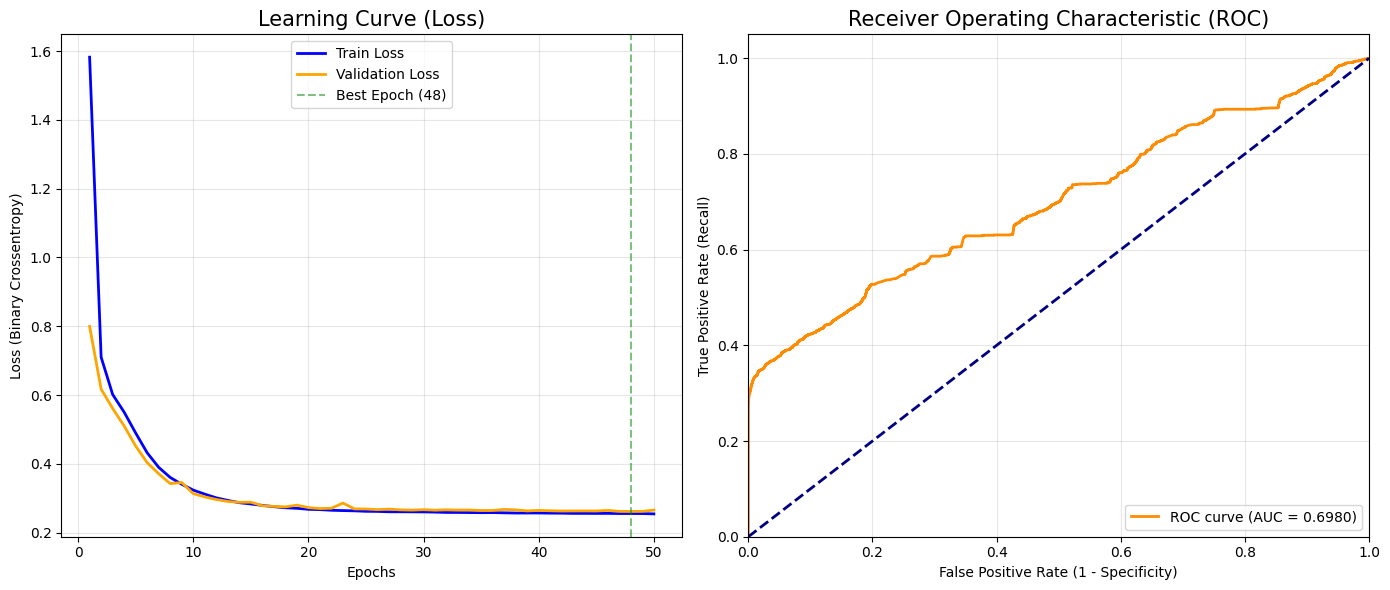

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_performance_graphs(history, y_true, y_prob):
    """
    1. Learning Curve (Loss 변화)
    2. ROC Curve (AUC 포함)
    두 가지 그래프를 나란히 그립니다.
    """
    
    # 캔버스 설정 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 1. Learning Curve (Loss) ---
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(1, len(loss) + 1)
    
    axes[0].plot(epochs_range, loss, label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
    axes[0].set_title('Learning Curve (Loss)', fontsize=15)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Binary Crossentropy)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Early Stopping 등으로 인해 학습이 끊긴 지점 표시 (선택사항)
    best_epoch = np.argmin(val_loss) + 1
    axes[0].axvline(best_epoch, linestyle='--', color='green', alpha=0.5, label=f'Best Epoch ({best_epoch})')
    axes[0].legend()

    # --- 2. ROC Curve & AUC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 기준선
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=15)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행부
# history: model.fit()의 반환 객체
# y_true: 실제값 (Yte)
# y_prob: 모델 예측 확률값
# ==========================================
print("\n[Visualizing] Learning Curve와 ROC Curve를 그립니다...")
plot_performance_graphs(history, y_true, y_prob)

In [2]:
import os, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Tensorflow 관련 제거하고 Scikit-Learn RandomForest 추가
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, optimizers, callbacks

# Optuna
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.model_selection import StratifiedKFold
import gc
import xgboost as xgb
# =========================
# CONFIG
# =========================
SEED = 1
MODE = "STRICT_CAUSAL"
SPLIT_STRATEGY = "RANDOM_ROW"
POS_RATIO = 0.10
TARGET_TOTAL = 100_000

EPOCHS = 50           # 최종 재학습 epoch
VAL_FRAC = 0.15
TEST_FRAC = 0.15
TIME_HOLDOUT_TEST_WEEKS = 8
TOL = 0.0025

# ✅ Optuna(튜닝) 전용 설정
N_TRIALS = 10             # Optuna trial 수
EPOCHS_TUNE = 15         # 튜닝용 epoch (CV 안에서)
MAX_TUNE_SAMPLES = 30_000  # fold별 train에서 최대 이만큼만 사용

# 최종 평가용 threshold
OPERATING_THR = 0.5
DATA_DIR = "."
# 고정 시드
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED);
rng = np.random.RandomState(SEED)

# 1. Base 데이터 (v0) 로드
path_v0 = os.path.join(DATA_DIR, "featured_all.parquet")
print(f"[LOAD] Base: {path_v0}")
final_data = pd.read_parquet(path_v0)

print(f"\n[FINAL DATA] Total Shape: {final_data.shape}")
print("========================================")

# =========================
# 수동 metric + AUC 계산 함수
# =========================
def compute_roc_auc_manual(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    # NaN 제거
    mask = ~np.isnan(y_prob)
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # 확률 내림차순 정렬
    order = np.argsort(-y_prob)
    y_true_sorted = y_true[order]

    cum_pos = np.cumsum(y_true_sorted == 1)
    cum_neg = np.cumsum(y_true_sorted == 0)

    tpr = cum_pos / n_pos
    fpr = cum_neg / n_neg

    # 사다리꼴 적분
    auc = 0.0
    prev_fpr = 0.0
    prev_tpr = 0.0
    for i in range(len(y_true_sorted)):
        auc += (fpr[i] - prev_fpr) * (tpr[i] + prev_tpr) / 2.0
        prev_fpr = fpr[i]
        prev_tpr = tpr[i]

    return float(auc)


# =========================
# 수동 metric + AUC + AIC/BIC 계산 함수
# =========================
def compute_aic_bic_manual(y_true, y_prob, n_features):
    """
    Log-Likelihood를 기반으로 AIC, BIC 계산
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    
    # Log(0) 방지를 위한 clipping (epsilon)
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    # Log Likelihood 계산
    # L = sum( y*log(p) + (1-y)*log(1-p) )
    log_likelihood = np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    
    n = len(y_true)
    k = n_features
    
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    return float(aic), float(bic), float(log_likelihood)

def compute_classification_metrics(y_true, y_prob, thr=0.8, n_features=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= thr).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    n = len(y_true)
    eps = 1e-9

    accuracy    = (tp + tn) / (n + eps)
    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1          = 2 * precision * recall / (precision + recall + eps)

    roc_auc = compute_roc_auc_manual(y_true, y_prob)

    metrics = {
        "accuracy":       float(accuracy),
        "precision":      float(precision),
        "recall":         float(recall),
        "specificity":    float(specificity),
        "f1":             float(f1),
        "roc_auc":        float(roc_auc),
        "n_eval":         int(n),
        "pos_rate_eval":  float(y_true.mean()),
    }

    # [추가됨] n_features가 들어오면 AIC/BIC 계산
    if n_features is not None:
        aic, bic, ll = compute_aic_bic_manual(y_true, y_prob, n_features)
        metrics["aic"] = aic
        metrics["bic"] = bic
        metrics["log_likelihood"] = ll
        metrics["n_features"] = int(n_features)

    cm = (tn, fp, fn, tp)
    return metrics, cm


# =========================
# SPLIT
# =========================
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")

def check_ratio(df, target_ratio=0.10, tol=TOL, name="dataset"):
    if len(df) == 0: return
    r = float(df["is_purchased"].mean())
    ok = abs(r - target_ratio) <= tol
    print(f"[check {name}] pos_rate={r:.6f}  target={target_ratio:.2f}  diff={r-target_ratio:+.6f}  {'OK' if ok else 'WARN'}")

def stratified_fixed_sample(df, target_col="is_purchased", total_n=100_000, pos_ratio=0.10, seed=SEED):
    n_pos_k = int(round(total_n * pos_ratio))
    n_neg_k = total_n - n_pos_k
    pos = df[df[target_col] == 1]
    neg = df[df[target_col] == 0]
    pos_s = pos.sample(n=min(n_pos_k, len(pos)), random_state=seed, replace=False)
    neg_s = neg.sample(n=min(n_neg_k, len(neg)), random_state=seed, replace=False)
    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def split_random_row_simple(df, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    rng_local = np.random.RandomState(seed)
    N = len(df)
    idx = np.arange(N); rng_local.shuffle(idx)
    n_test = int(round(N * test_frac))
    n_val  = int(round(N * val_frac))
    te_idx = idx[:n_test]
    va_idx = idx[n_test:n_test+n_val]
    tr_idx = idx[n_test+n_val:]
    te = df.iloc[te_idx].reset_index(drop=True)
    va = df.iloc[va_idx].reset_index(drop=True)
    tr = df.iloc[tr_idx].reset_index(drop=True)
    return tr, va, te

dataset = final_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
brief("dataset(raw)", dataset)
if TARGET_TOTAL and len(dataset) > TARGET_TOTAL:
    dataset = stratified_fixed_sample(dataset, target_col="is_purchased",
                                      total_n=TARGET_TOTAL, pos_ratio=POS_RATIO, seed=SEED)
brief("dataset(after 100K sampling)", dataset)
check_ratio(dataset, POS_RATIO, name="dataset(100K)")

if SPLIT_STRATEGY == "RANDOM_ROW":
    train_df, val_df, test_df = split_random_row_simple(dataset)
elif SPLIT_STRATEGY == "TIME_HOLDOUT":
    train_df, val_df, test_df = split_time_holdout(dataset)
else:
    train_df, val_df, test_df = split_user_disjoint(dataset)
    
TARGET = "is_purchased"

# =======================================================
# 1. Base Features (v0) - 총 41개
# : 캠페인, 채널, 플랫폼, 기본 이력 통계 등 가장 기초적인 정보
# =======================================================
cols_v0 = [
    'avg_campaign_duration', 'avg_time_since_complaint', 'avg_time_since_first_purchase',
    'avg_time_since_last_click', 'avg_time_since_last_open', 'avg_time_since_unsubscribe',
    'camp_campaign_typebulk', 'camp_campaign_typetransactional', 'camp_campaign_typetrigger',
    'camp_channelemail', 'camp_channelmobile_push', 'camp_channelmultichannel', 'camp_channelsms',
    'camp_topicevent', 'camp_topichappy.birthday', 'camp_topicleave.review',
    'camp_topicoffer.after.purchase', 'camp_topicother', 'camp_topicsale.out',
    'channel_email', 'channel_mobile_push', 'channel_web_push',
    'email_provider_gmail.com', 'email_provider_mail.ru', 'email_provider_other',
    'is_holiday',
    'message_type_bulk', 'message_type_transactional', 'message_type_trigger',
    'platform.', 'platform.desktop', 'platform.phablet', 'platform.smartphone', 'platform.tablet',
    'prev_is_clicked', 'prev_is_complained', 'prev_is_opened', 'prev_is_unsubscribed',
    'total_campaigns', 'total_messages', 'total_purchases'
]

# =======================================================
# 2. Add-on Features (v1) - 총 3개
# : 구매 주기 및 행동 위험도 (Hazard/Refraction)
# =======================================================
cols_v1 = [
    'days_since_last_purchase',
    'feat_rtb_hazard',
    'feat_postbuy_refrac'
]

# =======================================================
# 3. Add-on Features (v2) - 총 6개
# : 캘린더 효과(주말/월초) 및 시간대 이동(Shift)
# =======================================================
cols_v2 = [
    'cal_is_weekend',
    'cal_week_of_month',
    'feat_dow_shift',
    'feat_eoq_bump',
    'feat_hour_shift',
    'feat_payday_bump'
]

# =======================================================
# 4. Add-on Features (v3) - 총 9개
# : 유저 피로도(Fatigue) 및 최근 30일 반응률(Context)
# =======================================================
cols_v3 = [
    'ctx_tc_open_rate_30d',
    'feat_fatigue',
    'feat_last_any_hours',
    'feat_last_email_hours',
    'feat_last_mobile_push_hours',
    'u_cadence_std_30d',
    'u_click_rate_30d',
    'u_open_cnt_30d',
    'u_open_rate_30d'
]

# =======================================================
# 5. Add-on Features (v4) - 총 5개
# : 토픽 신선도 및 행동 경로 유사성 (Sequence/Path)
# =======================================================
cols_v4 = [
    'feat_like_last_success',
    'feat_path_align',
    'feat_topic_novelty',
    'topic_N7',
    'topic_t_since_hours'
]

def get_feat_cols(df):
    """
    데이터프레임에서 학습에 사용할 최종 수치형 변수 리스트를 반환합니다.
    Target과 제외 리스트(ID, Leakage, Collinear)를 필터링합니다.
    """
    # 1. 모든 수치형 컬럼 추출
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # 2. 제외 대상 필터링 (Target + Drop List)
    final_cols = list(cols_v0 + cols_v4)# + cols_v2 + cols_v3 + cols_v4)
    
    # 3. 정렬 (모델 재현성을 위해 이름순 정렬)
    return sorted(final_cols)

# -------------------------------------------------------
# 실행 및 결과 확인
# -------------------------------------------------------
# train_df는 이미 로드되어 있다고 가정
feat_cols = get_feat_cols(train_df)
n_feat = len(feat_cols)

def prepare_data_3d(df, feature_columns):
    X = df[feature_columns].fillna(0).astype(np.float32).to_numpy()
    Y = df[TARGET].fillna(0).astype(np.int32).to_numpy()
    X_3d = X.reshape(X.shape[0], X.shape[1], 1)  # (N, F, 1)
    return X_3d, Y

Xtr, Ytr = prepare_data_3d(train_df, feat_cols)
Xva, Yva = prepare_data_3d(val_df, feat_cols)
Xte, Yte = prepare_data_3d(test_df, feat_cols)

print("=== Data Shapes ===")
print(f"Train: X={Xtr.shape}, Y={Ytr.shape}")
print(f"Val  : X={Xva.shape}, Y={Yva.shape}")
print(f"Test : X={Xte.shape}, Y={Yte.shape}")


# =========================
# MODEL DEFINITION (CNN) - Dictionary 호환용 수정
# =========================
def build_cnn_model(params, input_shape):
    """
    Optuna trial 대신 확정된 파라미터 딕셔너리(params)를 받아 모델을 생성합니다.
    """
    inp = layers.Input(shape=input_shape)
    x = inp

    # Dictionary에서 파라미터 추출
    conv_filters    = params["conv_filters"]
    kernel_size     = params["kernel_size"]
    pool_size       = params["pool_size"]
    num_conv_layers = params["num_conv_layers"]
    dense_units     = params["dense_units"]
    dropout_rate    = params["dropout_rate"]
    l2_val          = params["l2"]

    for i in range(num_conv_layers):
        x = layers.Conv1D(
            filters=conv_filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="same",
            kernel_regularizer=regularizers.l2(l2_val),
        )(x)
        x = layers.MaxPooling1D(
            pool_size=pool_size,
            padding="same"
        )(x)

    x = layers.GlobalMaxPooling1D()(x)  # 1D CNN 필수

    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_val),
    )(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    return model

# =========================
# RETRAIN WITH BEST PARAMS
# =========================
print("\n[Final] Retraining CNN model with best hyperparameters...")
best_params_cnn = {
      "lr": 0.0001165012459217226,
      "batch_size": 32,
      "conv_filters": 224,
      "kernel_size": 2,
      "pool_size": 3,
      "num_conv_layers": 2,
      "dense_units": 192,
      "dropout_rate": 0.2402219960322026,
      "l2": 0.0014358772473434622
    }

tf.keras.backend.clear_session()

# [수정] create_model 대신 build_cnn_model 사용
final_model = build_cnn_model(best_params_cnn, (n_feat, 1))

opt = optimizers.Adam(learning_rate=best_params_cnn["lr"])
final_model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

es = callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 전체 학습 데이터 사용
history = final_model.fit(
    Xtr, Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=best_params_cnn["batch_size"],
    verbose=1,
    callbacks=[es]
)

# =========================
# FINAL EVALUATION (수동 metric)
# =========================
# [수정] model -> final_model 로 변경
y_prob = final_model.predict(Xte, verbose=0).ravel()
y_true = Yte

# 피처 개수 추출
n_features_used = Xte.shape[1]

# AIC/BIC 계산 포함 평가
final_metrics, (tn, fp, fn, tp) = compute_classification_metrics(
    y_true, y_prob, thr=OPERATING_THR, n_features=n_features_used
)

final_metrics.update({
    "mode": MODE,
    "split": SPLIT_STRATEGY,
    "best_params": best_params_cnn  # [수정] mlp -> cnn
})

print(json.dumps({"metrics": final_metrics}, indent=2))
print("confusion_matrix [tn fp fn tp]:", tn, fp, fn, tp)

[LOAD] Base: ./featured_all.parquet

[FINAL DATA] Total Shape: (433520, 124)
[dataset(raw)] n=433,520  pos=43,352  rate=0.100000
[dataset(after 100K sampling)] n=100,000  pos=10,000  rate=0.100000
[check dataset(100K)] pos_rate=0.100000  target=0.10  diff=+0.000000  OK
=== Data Shapes ===
Train: X=(70000, 46, 1), Y=(70000,)
Val  : X=(15000, 46, 1), Y=(15000,)
Test : X=(15000, 46, 1), Y=(15000,)

[Final] Retraining CNN model with best hyperparameters...
Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - auc: 0.6358 - loss: 1.7533 - val_auc: 0.7228 - val_loss: 0.6320
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.6786 - loss: 0.6723 - val_auc: 0.7506 - val_loss: 0.5676
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.7032 - loss: 0.5823 - val_auc: 0.7272 - val_loss: 0.5441
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.7081 - loss: 0.5181 - val_auc: 0.7445 - val_loss: 0.4794
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0


[Visualizing] Learning Curve와 ROC Curve를 그립니다...


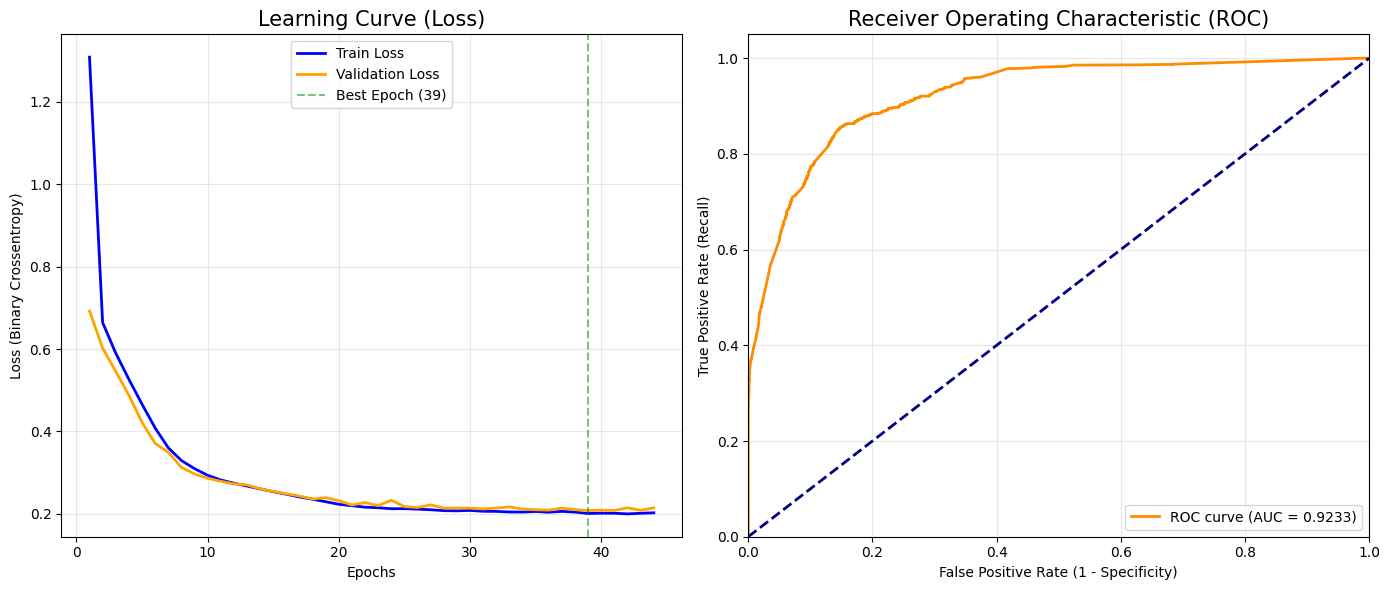

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_performance_graphs(history, y_true, y_prob):
    """
    1. Learning Curve (Loss 변화)
    2. ROC Curve (AUC 포함)
    두 가지 그래프를 나란히 그립니다.
    """
    
    # 캔버스 설정 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 1. Learning Curve (Loss) ---
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(1, len(loss) + 1)
    
    axes[0].plot(epochs_range, loss, label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
    axes[0].set_title('Learning Curve (Loss)', fontsize=15)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Binary Crossentropy)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Early Stopping 등으로 인해 학습이 끊긴 지점 표시 (선택사항)
    best_epoch = np.argmin(val_loss) + 1
    axes[0].axvline(best_epoch, linestyle='--', color='green', alpha=0.5, label=f'Best Epoch ({best_epoch})')
    axes[0].legend()

    # --- 2. ROC Curve & AUC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 기준선
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=15)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행부
# history: model.fit()의 반환 객체
# y_true: 실제값 (Yte)
# y_prob: 모델 예측 확률값
# ==========================================
print("\n[Visualizing] Learning Curve와 ROC Curve를 그립니다...")
plot_performance_graphs(history, y_true, y_prob)

In [3]:
import os, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Tensorflow 관련 제거하고 Scikit-Learn RandomForest 추가
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, optimizers, callbacks

# Optuna
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.model_selection import StratifiedKFold
import gc
import xgboost as xgb
# =========================
# CONFIG
# =========================
SEED = 1
MODE = "STRICT_CAUSAL"
SPLIT_STRATEGY = "RANDOM_ROW"
POS_RATIO = 0.10
TARGET_TOTAL = 100_000

EPOCHS = 50           # 최종 재학습 epoch
VAL_FRAC = 0.15
TEST_FRAC = 0.15
TIME_HOLDOUT_TEST_WEEKS = 8
TOL = 0.0025

# ✅ Optuna(튜닝) 전용 설정
N_TRIALS = 10             # Optuna trial 수
EPOCHS_TUNE = 15         # 튜닝용 epoch (CV 안에서)
MAX_TUNE_SAMPLES = 30_000  # fold별 train에서 최대 이만큼만 사용

# 최종 평가용 threshold
OPERATING_THR = 0.5
DATA_DIR = "."
# 고정 시드
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED);
rng = np.random.RandomState(SEED)

# 1. Base 데이터 (v0) 로드
path_v0 = os.path.join(DATA_DIR, "featured_all.parquet")
print(f"[LOAD] Base: {path_v0}")
final_data = pd.read_parquet(path_v0)

print(f"\n[FINAL DATA] Total Shape: {final_data.shape}")
print("========================================")

# =========================
# 수동 metric + AUC 계산 함수
# =========================
def compute_roc_auc_manual(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    # NaN 제거
    mask = ~np.isnan(y_prob)
    y_true = y_true[mask]
    y_prob = y_prob[mask]

    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # 확률 내림차순 정렬
    order = np.argsort(-y_prob)
    y_true_sorted = y_true[order]

    cum_pos = np.cumsum(y_true_sorted == 1)
    cum_neg = np.cumsum(y_true_sorted == 0)

    tpr = cum_pos / n_pos
    fpr = cum_neg / n_neg

    # 사다리꼴 적분
    auc = 0.0
    prev_fpr = 0.0
    prev_tpr = 0.0
    for i in range(len(y_true_sorted)):
        auc += (fpr[i] - prev_fpr) * (tpr[i] + prev_tpr) / 2.0
        prev_fpr = fpr[i]
        prev_tpr = tpr[i]

    return float(auc)


# =========================
# 수동 metric + AUC + AIC/BIC 계산 함수
# =========================
def compute_aic_bic_manual(y_true, y_prob, n_features):
    """
    Log-Likelihood를 기반으로 AIC, BIC 계산
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    
    # Log(0) 방지를 위한 clipping (epsilon)
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    # Log Likelihood 계산
    # L = sum( y*log(p) + (1-y)*log(1-p) )
    log_likelihood = np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    
    n = len(y_true)
    k = n_features
    
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    return float(aic), float(bic), float(log_likelihood)

def compute_classification_metrics(y_true, y_prob, thr=0.8, n_features=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= thr).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    n = len(y_true)
    eps = 1e-9

    accuracy    = (tp + tn) / (n + eps)
    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1          = 2 * precision * recall / (precision + recall + eps)

    roc_auc = compute_roc_auc_manual(y_true, y_prob)

    metrics = {
        "accuracy":       float(accuracy),
        "precision":      float(precision),
        "recall":         float(recall),
        "specificity":    float(specificity),
        "f1":             float(f1),
        "roc_auc":        float(roc_auc),
        "n_eval":         int(n),
        "pos_rate_eval":  float(y_true.mean()),
    }

    # [추가됨] n_features가 들어오면 AIC/BIC 계산
    if n_features is not None:
        aic, bic, ll = compute_aic_bic_manual(y_true, y_prob, n_features)
        metrics["aic"] = aic
        metrics["bic"] = bic
        metrics["log_likelihood"] = ll
        metrics["n_features"] = int(n_features)

    cm = (tn, fp, fn, tp)
    return metrics, cm


# =========================
# SPLIT
# =========================
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")
def brief(name, df):
    if df is None or len(df) == 0:
        print(f"[{name}] n=0"); return
    pos = int(df["is_purchased"].sum())
    n = len(df); rate = pos / max(n, 1)
    print(f"[{name}] n={n:,}  pos={pos:,}  rate={rate:.6f}")

def check_ratio(df, target_ratio=0.10, tol=TOL, name="dataset"):
    if len(df) == 0: return
    r = float(df["is_purchased"].mean())
    ok = abs(r - target_ratio) <= tol
    print(f"[check {name}] pos_rate={r:.6f}  target={target_ratio:.2f}  diff={r-target_ratio:+.6f}  {'OK' if ok else 'WARN'}")

def stratified_fixed_sample(df, target_col="is_purchased", total_n=100_000, pos_ratio=0.10, seed=SEED):
    n_pos_k = int(round(total_n * pos_ratio))
    n_neg_k = total_n - n_pos_k
    pos = df[df[target_col] == 1]
    neg = df[df[target_col] == 0]
    pos_s = pos.sample(n=min(n_pos_k, len(pos)), random_state=seed, replace=False)
    neg_s = neg.sample(n=min(n_neg_k, len(neg)), random_state=seed, replace=False)
    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def split_random_row_simple(df, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    rng_local = np.random.RandomState(seed)
    N = len(df)
    idx = np.arange(N); rng_local.shuffle(idx)
    n_test = int(round(N * test_frac))
    n_val  = int(round(N * val_frac))
    te_idx = idx[:n_test]
    va_idx = idx[n_test:n_test+n_val]
    tr_idx = idx[n_test+n_val:]
    te = df.iloc[te_idx].reset_index(drop=True)
    va = df.iloc[va_idx].reset_index(drop=True)
    tr = df.iloc[tr_idx].reset_index(drop=True)
    return tr, va, te

dataset = final_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
brief("dataset(raw)", dataset)
if TARGET_TOTAL and len(dataset) > TARGET_TOTAL:
    dataset = stratified_fixed_sample(dataset, target_col="is_purchased",
                                      total_n=TARGET_TOTAL, pos_ratio=POS_RATIO, seed=SEED)
brief("dataset(after 100K sampling)", dataset)
check_ratio(dataset, POS_RATIO, name="dataset(100K)")

if SPLIT_STRATEGY == "RANDOM_ROW":
    train_df, val_df, test_df = split_random_row_simple(dataset)
elif SPLIT_STRATEGY == "TIME_HOLDOUT":
    train_df, val_df, test_df = split_time_holdout(dataset)
else:
    train_df, val_df, test_df = split_user_disjoint(dataset)
    
TARGET = "is_purchased"

# =======================================================
# 1. Base Features (v0) - 총 41개
# : 캠페인, 채널, 플랫폼, 기본 이력 통계 등 가장 기초적인 정보
# =======================================================
cols_v0 = [
    'avg_campaign_duration', 'avg_time_since_complaint', 'avg_time_since_first_purchase',
    'avg_time_since_last_click', 'avg_time_since_last_open', 'avg_time_since_unsubscribe',
    'camp_campaign_typebulk', 'camp_campaign_typetransactional', 'camp_campaign_typetrigger',
    'camp_channelemail', 'camp_channelmobile_push', 'camp_channelmultichannel', 'camp_channelsms',
    'camp_topicevent', 'camp_topichappy.birthday', 'camp_topicleave.review',
    'camp_topicoffer.after.purchase', 'camp_topicother', 'camp_topicsale.out',
    'channel_email', 'channel_mobile_push', 'channel_web_push',
    'email_provider_gmail.com', 'email_provider_mail.ru', 'email_provider_other',
    'is_holiday',
    'message_type_bulk', 'message_type_transactional', 'message_type_trigger',
    'platform.', 'platform.desktop', 'platform.phablet', 'platform.smartphone', 'platform.tablet',
    'prev_is_clicked', 'prev_is_complained', 'prev_is_opened', 'prev_is_unsubscribed',
    'total_campaigns', 'total_messages', 'total_purchases'
]

# =======================================================
# 2. Add-on Features (v1) - 총 3개
# : 구매 주기 및 행동 위험도 (Hazard/Refraction)
# =======================================================
cols_v1 = [
    'days_since_last_purchase',
    'feat_rtb_hazard',
    'feat_postbuy_refrac'
]

# =======================================================
# 3. Add-on Features (v2) - 총 6개
# : 캘린더 효과(주말/월초) 및 시간대 이동(Shift)
# =======================================================
cols_v2 = [
    'cal_is_weekend',
    'cal_week_of_month',
    'feat_dow_shift',
    'feat_eoq_bump',
    'feat_hour_shift',
    'feat_payday_bump'
]

# =======================================================
# 4. Add-on Features (v3) - 총 9개
# : 유저 피로도(Fatigue) 및 최근 30일 반응률(Context)
# =======================================================
cols_v3 = [
    'ctx_tc_open_rate_30d',
    'feat_fatigue',
    'feat_last_any_hours',
    'feat_last_email_hours',
    'feat_last_mobile_push_hours',
    'u_cadence_std_30d',
    'u_click_rate_30d',
    'u_open_cnt_30d',
    'u_open_rate_30d'
]

# =======================================================
# 5. Add-on Features (v4) - 총 5개
# : 토픽 신선도 및 행동 경로 유사성 (Sequence/Path)
# =======================================================
cols_v4 = [
    'feat_like_last_success',
    'feat_path_align',
    'feat_topic_novelty',
    'topic_N7',
    'topic_t_since_hours'
]

def get_feat_cols(df):
    """
    데이터프레임에서 학습에 사용할 최종 수치형 변수 리스트를 반환합니다.
    Target과 제외 리스트(ID, Leakage, Collinear)를 필터링합니다.
    """
    # 1. 모든 수치형 컬럼 추출
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # 2. 제외 대상 필터링 (Target + Drop List)
    final_cols = list(cols_v0 + cols_v1 + cols_v2 + cols_v3 + cols_v4)
    
    # 3. 정렬 (모델 재현성을 위해 이름순 정렬)
    return sorted(final_cols)

# -------------------------------------------------------
# 실행 및 결과 확인
# -------------------------------------------------------
# train_df는 이미 로드되어 있다고 가정
feat_cols = get_feat_cols(train_df)
n_feat = len(feat_cols)

def prepare_data_3d(df, feature_columns):
    X = df[feature_columns].fillna(0).astype(np.float32).to_numpy()
    Y = df[TARGET].fillna(0).astype(np.int32).to_numpy()
    X_3d = X.reshape(X.shape[0], X.shape[1], 1)  # (N, F, 1)
    return X_3d, Y

Xtr, Ytr = prepare_data_3d(train_df, feat_cols)
Xva, Yva = prepare_data_3d(val_df, feat_cols)
Xte, Yte = prepare_data_3d(test_df, feat_cols)

print("=== Data Shapes ===")
print(f"Train: X={Xtr.shape}, Y={Ytr.shape}")
print(f"Val  : X={Xva.shape}, Y={Yva.shape}")
print(f"Test : X={Xte.shape}, Y={Yte.shape}")


# =========================
# MODEL DEFINITION (CNN) - Dictionary 호환용 수정
# =========================
def build_cnn_model(params, input_shape):
    """
    Optuna trial 대신 확정된 파라미터 딕셔너리(params)를 받아 모델을 생성합니다.
    """
    inp = layers.Input(shape=input_shape)
    x = inp

    # Dictionary에서 파라미터 추출
    conv_filters    = params["conv_filters"]
    kernel_size     = params["kernel_size"]
    pool_size       = params["pool_size"]
    num_conv_layers = params["num_conv_layers"]
    dense_units     = params["dense_units"]
    dropout_rate    = params["dropout_rate"]
    l2_val          = params["l2"]

    for i in range(num_conv_layers):
        x = layers.Conv1D(
            filters=conv_filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="same",
            kernel_regularizer=regularizers.l2(l2_val),
        )(x)
        x = layers.MaxPooling1D(
            pool_size=pool_size,
            padding="same"
        )(x)

    x = layers.GlobalMaxPooling1D()(x)  # 1D CNN 필수

    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_val),
    )(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    return model

# =========================
# RETRAIN WITH BEST PARAMS
# =========================
print("\n[Final] Retraining CNN model with best hyperparameters...")
best_params_cnn = {
      "lr": 0.0001165012459217226,
      "batch_size": 32,
      "conv_filters": 224,
      "kernel_size": 2,
      "pool_size": 3,
      "num_conv_layers": 2,
      "dense_units": 192,
      "dropout_rate": 0.2402219960322026,
      "l2": 0.0014358772473434622
    }

tf.keras.backend.clear_session()

# [수정] create_model 대신 build_cnn_model 사용
final_model = build_cnn_model(best_params_cnn, (n_feat, 1))

opt = optimizers.Adam(learning_rate=best_params_cnn["lr"])
final_model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

es = callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 전체 학습 데이터 사용
history = final_model.fit(
    Xtr, Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=best_params_cnn["batch_size"],
    verbose=1,
    callbacks=[es]
)

# =========================
# FINAL EVALUATION (수동 metric)
# =========================
# [수정] model -> final_model 로 변경
y_prob = final_model.predict(Xte, verbose=0).ravel()
y_true = Yte

# 피처 개수 추출
n_features_used = Xte.shape[1]

# AIC/BIC 계산 포함 평가
final_metrics, (tn, fp, fn, tp) = compute_classification_metrics(
    y_true, y_prob, thr=OPERATING_THR, n_features=n_features_used
)

final_metrics.update({
    "mode": MODE,
    "split": SPLIT_STRATEGY,
    "best_params": best_params_cnn  # [수정] mlp -> cnn
})

print(json.dumps({"metrics": final_metrics}, indent=2))
print("confusion_matrix [tn fp fn tp]:", tn, fp, fn, tp)

[LOAD] Base: ./featured_all.parquet

[FINAL DATA] Total Shape: (433520, 124)
[dataset(raw)] n=433,520  pos=43,352  rate=0.100000
[dataset(after 100K sampling)] n=100,000  pos=10,000  rate=0.100000
[check dataset(100K)] pos_rate=0.100000  target=0.10  diff=+0.000000  OK
=== Data Shapes ===
Train: X=(70000, 64, 1), Y=(70000,)
Val  : X=(15000, 64, 1), Y=(15000,)
Test : X=(15000, 64, 1), Y=(15000,)

[Final] Retraining CNN model with best hyperparameters...
Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - auc: 0.7671 - loss: 2.1878 - val_auc: 0.8683 - val_loss: 0.5993
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0.8652 - loss: 0.6073 - val_auc: 0.8897 - val_loss: 0.5311
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - auc: 0.8719 - loss: 0.5388 - val_auc: 0.8651 - val_loss: 0.4927
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - auc: 0.8756 - loss: 0.4856 - val_auc: 0.9067 - val_loss: 0.4077
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - auc: 0


[Visualizing] Learning Curve와 ROC Curve를 그립니다...


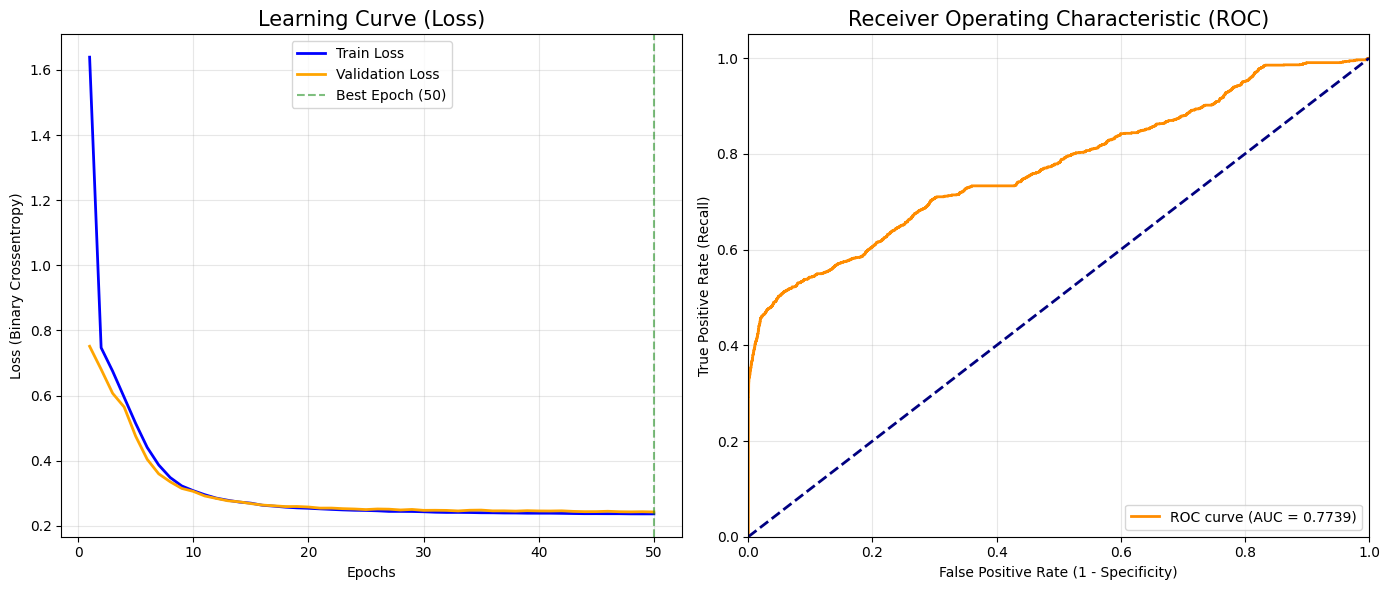

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_performance_graphs(history, y_true, y_prob):
    """
    1. Learning Curve (Loss 변화)
    2. ROC Curve (AUC 포함)
    두 가지 그래프를 나란히 그립니다.
    """
    
    # 캔버스 설정 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 1. Learning Curve (Loss) ---
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(1, len(loss) + 1)
    
    axes[0].plot(epochs_range, loss, label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
    axes[0].set_title('Learning Curve (Loss)', fontsize=15)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Binary Crossentropy)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Early Stopping 등으로 인해 학습이 끊긴 지점 표시 (선택사항)
    best_epoch = np.argmin(val_loss) + 1
    axes[0].axvline(best_epoch, linestyle='--', color='green', alpha=0.5, label=f'Best Epoch ({best_epoch})')
    axes[0].legend()

    # --- 2. ROC Curve & AUC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 기준선
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=15)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행부
# history: model.fit()의 반환 객체
# y_true: 실제값 (Yte)
# y_prob: 모델 예측 확률값
# ==========================================
print("\n[Visualizing] Learning Curve와 ROC Curve를 그립니다...")
plot_performance_graphs(history, y_true, y_prob)